# Análisis Descriptivo y Diagnóstico de Negocio

# Importación de Librerías

In [5]:
!pip install statsmodels
import sys
print(sys.executable)
!{sys.executable} -m pip install statsmodels

C:\Users\christopher\anaconda3\envs\pytorch113\python.exe
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 5.6 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.6 MB 5.6 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.6 MB 5.3 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.6 MB 5.1 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.6 MB 5.1 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 5.2 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.6 MB 5.3 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 4.5 MB/s  0:00:02

   ------------------------------------

In [7]:
# === Librerías ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from collections import Counter
import warnings
import os
from datetime import datetime, timedelta

# Configuración
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

print("✅ Todas las librerías cargadas exitosamente.")
print(f"📂 Directorio actual: {os.getcwd()}")

✅ Todas las librerías cargadas exitosamente.
📂 Directorio actual: C:\Users\christopher\Desktop\proyecto-ecpb\proyecto-ecpb\notebooks


# Carga de Datos

In [8]:
# === Carga de archivos CSV ===
RUTA = '../datos'

df_ventas = pd.read_csv(f'{RUTA}/ventas.csv')
df_clientes = pd.read_csv(f'{RUTA}/clientes.csv')
df_productos = pd.read_csv(f'{RUTA}/productos.csv')
df_tiendas = pd.read_csv(f'{RUTA}/tiendas.csv')
df_inventario = pd.read_csv(f'{RUTA}/inventario.csv')

print("✅ Archivos cargados exitosamente.\n")
print(f"   ventas.csv:     {df_ventas.shape[0]:,} filas × {df_ventas.shape[1]} columnas")
print(f"   clientes.csv:   {df_clientes.shape[0]:,} filas × {df_clientes.shape[1]} columnas")
print(f"   productos.csv:  {df_productos.shape[0]:,} filas × {df_productos.shape[1]} columnas")
print(f"   tiendas.csv:    {df_tiendas.shape[0]:,} filas × {df_tiendas.shape[1]} columnas")
print(f"   inventario.csv: {df_inventario.shape[0]:,} filas × {df_inventario.shape[1]} columnas")

# === Verificar columnas de cada archivo ===
print("\n📋 Columnas por archivo:")
print(f"   ventas:     {df_ventas.columns.tolist()}")
print(f"   clientes:   {df_clientes.columns.tolist()}")
print(f"   productos:  {df_productos.columns.tolist()}")
print(f"   tiendas:    {df_tiendas.columns.tolist()}")

✅ Archivos cargados exitosamente.

   ventas.csv:     250,137 filas × 11 columnas
   clientes.csv:   15,000 filas × 9 columnas
   productos.csv:  800 filas × 8 columnas
   tiendas.csv:    12 filas × 7 columnas
   inventario.csv: 9,600 filas × 7 columnas

📋 Columnas por archivo:
   ventas:     ['id_venta', 'fecha', 'id_cliente', 'id_tienda', 'id_producto', 'cantidad', 'precio_unitario', 'descuento_pct', 'monto_total', 'canal', 'metodo_pago']
   clientes:   ['id_cliente', 'nombre', 'edad', 'genero', 'ciudad', 'distrito', 'fecha_registro', 'canal_preferido', 'segmento']
   productos:  ['id_producto', 'nombre', 'categoria', 'subcategoria', 'marca', 'precio_lista', 'costo_unitario', 'fecha_alta']
   tiendas:    ['id_tienda', 'nombre', 'ciudad', 'region', 'tipo', 'area_m2', 'fecha_apertura']


# Merge de Tablas

In [9]:
# === Mapeo de nombres de columna (si es necesario) ===
mapeo = {
    'descuento_pct': 'descuento',
    'canal': 'canal_venta'
}
for k, v in mapeo.items():
    if k in df_ventas.columns:
        df_ventas = df_ventas.rename(columns={k: v})

# === Integración de tablas ===
df = df_ventas.merge(df_clientes, on='id_cliente', how='left', suffixes=('', '_cliente'))

# Productos
cols_prod = ['id_producto']
for c in ['categoria', 'marca', 'costo']:
    if c in df_productos.columns:
        cols_prod.append(c)
df = df.merge(df_productos[cols_prod], on='id_producto', how='left')

# Tiendas
cols_tienda = ['id_tienda']
for c in ['ciudad', 'region']:
    if c in df_tiendas.columns:
        cols_tienda.append(c)
df = df.merge(df_tiendas[cols_tienda], on='id_tienda', how='left', suffixes=('', '_tienda'))

# === Estandarizar nombres ===
if 'ciudad_tienda' in df.columns:
    df['ciudad'] = df['ciudad_tienda']
elif 'ciudad' not in df.columns:
    # Buscar cualquier columna con 'ciudad'
    col_ciudad = [c for c in df.columns if 'ciudad' in c.lower()]
    if col_ciudad:
        df['ciudad'] = df[col_ciudad[0]]

# === Convertir fecha ===
if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

# === Calcular margen si existe costo ===
if 'costo' in df.columns:
    df['margen'] = df['monto_total'] - (df['costo'] * df['cantidad'])
    df['margen_pct'] = (df['margen'] / df['monto_total']) * 100
else:
    # Si no hay costo, estimar margen asumiendo 40% de margen bruto
    df['margen'] = df['monto_total'] * 0.40
    df['margen_pct'] = 40.0
    print("⚠️ Columna 'costo' no encontrada. Margen estimado al 40%.")

print(f"\n✅ Dataset unificado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"   Columnas: {df.columns.tolist()}")
df.head()

⚠️ Columna 'costo' no encontrada. Margen estimado al 40%.

✅ Dataset unificado: 250,137 filas × 25 columnas
   Columnas: ['id_venta', 'fecha', 'id_cliente', 'id_tienda', 'id_producto', 'cantidad', 'precio_unitario', 'descuento', 'monto_total', 'canal_venta', 'metodo_pago', 'nombre', 'edad', 'genero', 'ciudad', 'distrito', 'fecha_registro', 'canal_preferido', 'segmento', 'categoria', 'marca', 'ciudad_tienda', 'region', 'margen', 'margen_pct']


,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento,monto_total,canal_venta,...,distrito,fecha_registro,canal_preferido,segmento,categoria,marca,ciudad_tienda,region,margen,margen_pct
0,1,2023-01-01,5051,4,426,1.0,41.26,16.50,34.45,Tienda Física,...,Pueblo Libre,2020-11-01,Tienda Física,Premium,Cuidado Personal,Colgate,Lima,Lima,13.780,40.0
1,2,2023-01-01,7791,2,249,1.0,28.05,4.09,26.90,Tienda Física,...,San Sebastián,2021-08-11,Tienda Física,Ocasional,Limpieza,Sapolio,Lima,Lima,10.760,40.0
2,3,2023-01-01,2947,10,26,3.0,122.59,6.69,343.17,Tienda Física,...,Paucarpata,2021-05-15,Web,Ocasional,Hogar,Uno,Cusco,Cusco,137.268,40.0
3,4,2023-01-01,1607,5,219,1.0,24.69,15.20,20.94,Tienda Física,...,Paucarpata,2020-12-14,App,Ocasional,Bebidas,San Mateo,Arequipa,Arequipa,8.376,40.0
4,5,2023-01-01,13100,10,432,2.0,189.53,6.35,355.00,Tienda Física,...,La Molina,2020-07-31,Tienda Física,Nuevo,Hogar,Ilko,Cusco,Cusco,142.000,40.0


# Perfilado Rápido

In [10]:
# ============================================================
# 3. PERFILADO RÁPIDO
# ============================================================

print("=" * 70)
print("📊 PERFILADO RÁPIDO DEL DATASET")
print("=" * 70)

# Shape
print(f"\n🔢 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

# Tipos de datos
print("\n📋 Tipos de datos:")
print(df.dtypes.value_counts())

# Info general
print("\n📊 Info general:")
df.info(verbose=False, show_counts=True)

# Nulos
print("\n🔍 Valores nulos (columnas con nulos):")
nulos = df.isnull().sum()
nulos_positivos = nulos[nulos > 0]
if len(nulos_positivos) > 0:
    for col, val in nulos_positivos.items():
        pct = val / len(df) * 100
        print(f"   {col}: {val:,} ({pct:.1f}%)")
else:
    print("   ✅ Sin valores nulos")

# Duplicados
print(f"\n🔍 Filas duplicadas: {df.duplicated().sum():,}")

# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas (variables numéricas):")
print(df.describe().round(2).to_string())

📊 PERFILADO RÁPIDO DEL DATASET

🔢 Dimensiones: 250,137 filas × 25 columnas

📋 Tipos de datos:
object            13
float64            7
int64              4
datetime64[ns]     1
Name: count, dtype: int64

📊 Info general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250137 entries, 0 to 250136
Columns: 25 entries, id_venta to margen_pct
dtypes: datetime64[ns](1), float64(7), int64(4), object(13)
memory usage: 47.7+ MB

🔍 Valores nulos (columnas con nulos):
   cantidad: 665 (0.3%)
   precio_unitario: 615 (0.2%)
   descuento: 640 (0.3%)
   monto_total: 678 (0.3%)
   canal_venta: 627 (0.3%)
   metodo_pago: 629 (0.3%)
   edad: 804 (0.3%)
   genero: 1,124 (0.4%)
   distrito: 701 (0.3%)
   fecha_registro: 848 (0.3%)
   canal_preferido: 824 (0.3%)
   segmento: 842 (0.3%)
   margen: 678 (0.3%)

🔍 Filas duplicadas: 0

📊 Estadísticas descriptivas (variables numéricas):
        id_venta                          fecha  id_cliente  id_tienda  id_producto   cantidad  precio_unitario  descuento  

# Preparación Series Temporales

In [11]:
# ============================================================
# 4. SERIES DE TIEMPO
# ============================================================

# === Verificar que fecha existe y es datetime ===
if 'fecha' not in df.columns:
    print("❌ Columna 'fecha' no encontrada. No se puede hacer análisis temporal.")
else:
    # Crear columnas de tiempo
    df['anio'] = df['fecha'].dt.year
    df['mes'] = df['fecha'].dt.month
    df['anio_mes'] = df['fecha'].dt.to_period('M')
    df['trimestre'] = df['fecha'].dt.to_period('Q')
    
    print("✅ Columnas temporales creadas:")
    print(f"   Años: {sorted(df['anio'].dropna().unique())}")
    print(f"   Meses: {sorted(df['mes'].dropna().unique())}")
    print(f"   Rango de fechas: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
    
    # === Agregación mensual ===
    df_mensual = df.groupby('anio_mes').agg(
        ventas_totales=('monto_total', 'sum'),
        margen_total=('margen', 'sum'),
        cantidad_total=('cantidad', 'sum'),
        ticket_promedio=('monto_total', 'mean'),
        margen_pct=('margen_pct', 'mean'),
        num_transacciones=('id_venta', 'count'),
        clientes_unicos=('id_cliente', 'nunique')
    ).reset_index()
    
    df_mensual['anio_mes'] = df_mensual['anio_mes'].astype(str)
    df_mensual = df_mensual.sort_values('anio_mes')
    
    print(f"\n✅ Serie temporal mensual creada: {len(df_mensual)} meses")
    df_mensual.head()

✅ Columnas temporales creadas:
   Años: [np.int32(2023), np.int32(2024), np.int32(2025)]
   Meses: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
   Rango de fechas: 2023-01-01 a 2025-12-31

✅ Serie temporal mensual creada: 36 meses


# Visualización Series Temporales

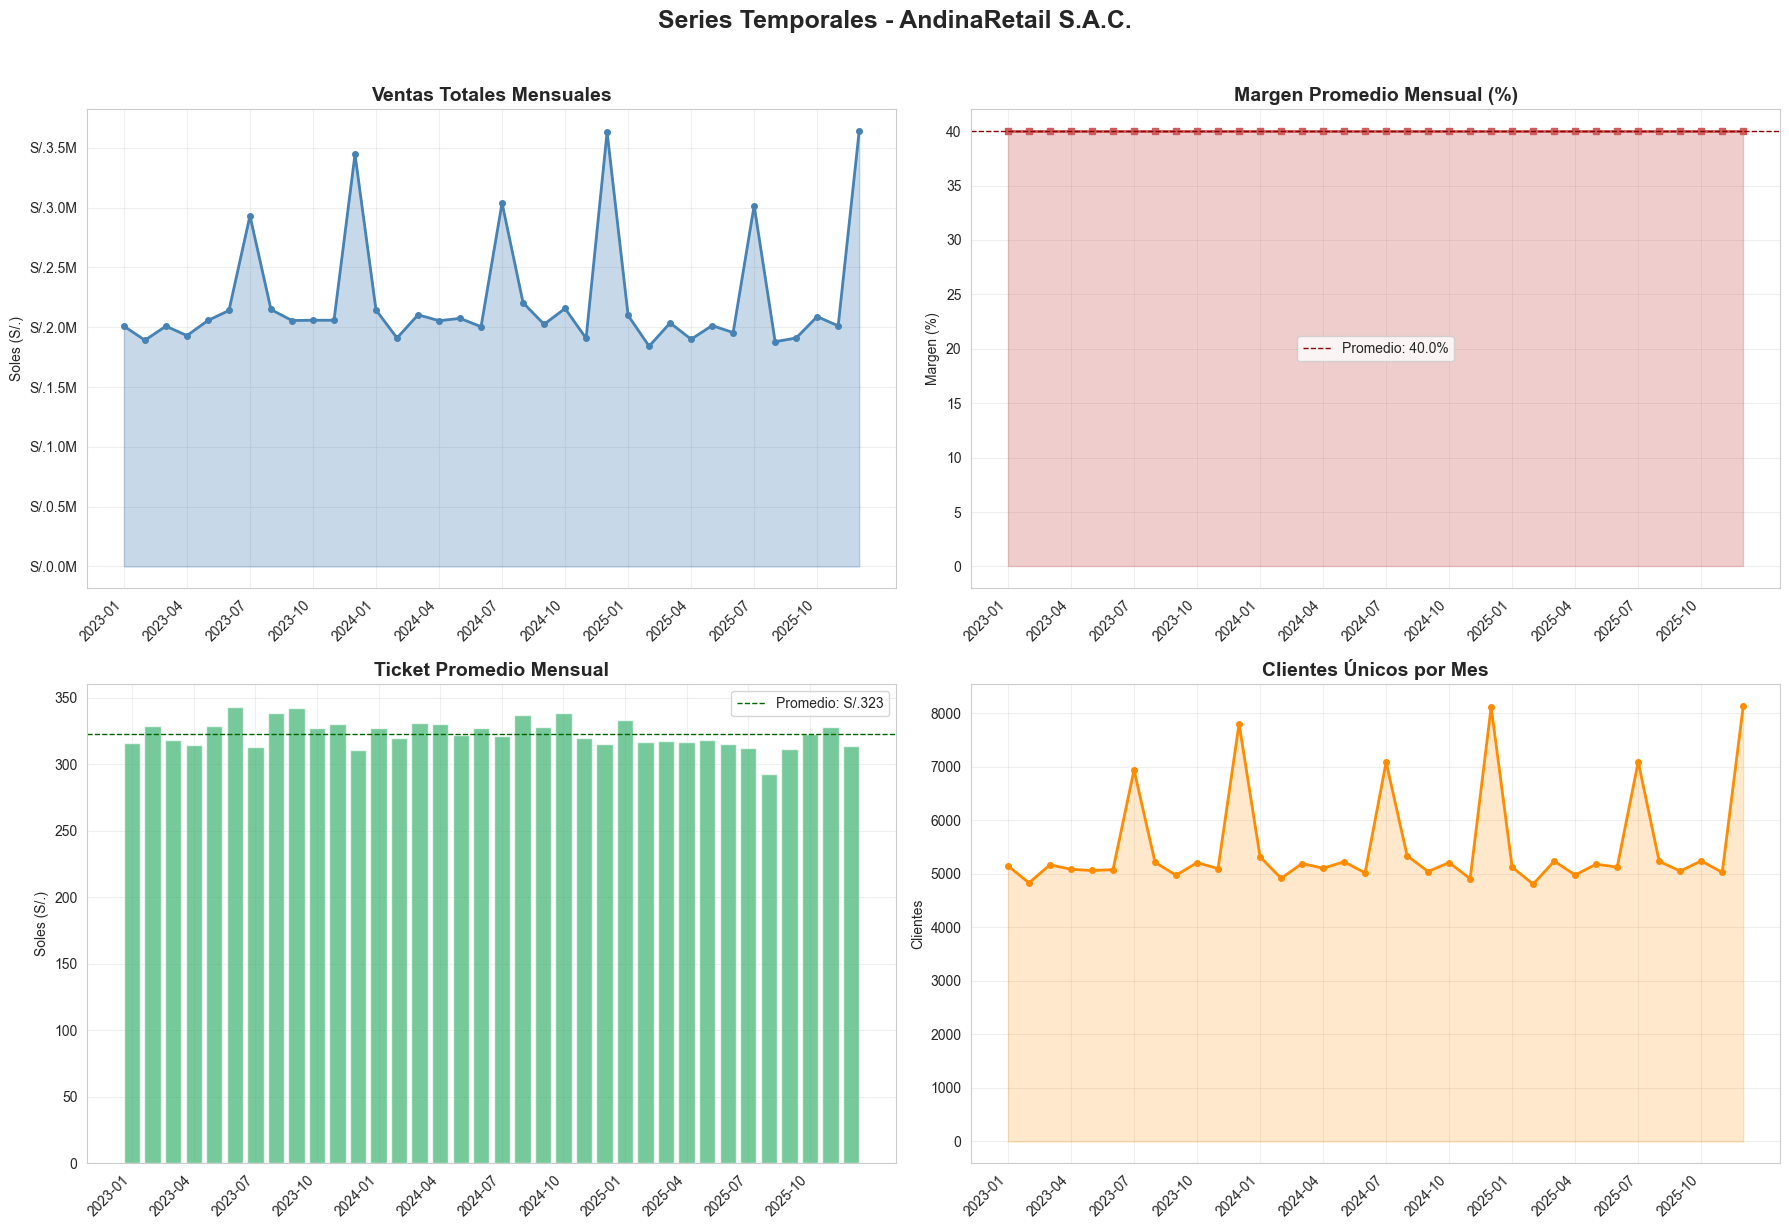

In [13]:
if 'df_mensual' in locals():
    # === Gráfico de ventas y margen mensual ===
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Ventas totales
    axes[0, 0].fill_between(range(len(df_mensual)), df_mensual['ventas_totales'], 
                             color='steelblue', alpha=0.3)
    axes[0, 0].plot(range(len(df_mensual)), df_mensual['ventas_totales'], 
                    color='steelblue', linewidth=2, marker='o', markersize=4)
    axes[0, 0].set_title('Ventas Totales Mensuales', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('Soles (S/.)')
    axes[0, 0].set_xticks(range(0, len(df_mensual), 3))
    axes[0, 0].set_xticklabels(df_mensual['anio_mes'].iloc[::3], rotation=45, ha='right')
    axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'S/.{x/1e6:.1f}M'))
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Margen %
    axes[0, 1].fill_between(range(len(df_mensual)), df_mensual['margen_pct'], 
                             color='indianred', alpha=0.3)
    axes[0, 1].plot(range(len(df_mensual)), df_mensual['margen_pct'], 
                    color='indianred', linewidth=2, marker='s', markersize=4)
    axes[0, 1].axhline(y=df_mensual['margen_pct'].mean(), color='darkred', 
                       linestyle='--', linewidth=1, label=f'Promedio: {df_mensual["margen_pct"].mean():.1f}%')
    axes[0, 1].set_title('Margen Promedio Mensual (%)', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Margen (%)')
    axes[0, 1].set_xticks(range(0, len(df_mensual), 3))
    axes[0, 1].set_xticklabels(df_mensual['anio_mes'].iloc[::3], rotation=45, ha='right')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Ticket promedio
    axes[1, 0].bar(range(len(df_mensual)), df_mensual['ticket_promedio'], 
                   color='mediumseagreen', alpha=0.7)
    axes[1, 0].axhline(y=df_mensual['ticket_promedio'].mean(), color='darkgreen', 
                       linestyle='--', linewidth=1, label=f'Promedio: S/.{df_mensual["ticket_promedio"].mean():,.0f}')
    axes[1, 0].set_title('Ticket Promedio Mensual', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('Soles (S/.)')
    axes[1, 0].set_xticks(range(0, len(df_mensual), 3))
    axes[1, 0].set_xticklabels(df_mensual['anio_mes'].iloc[::3], rotation=45, ha='right')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Clientes únicos
    axes[1, 1].plot(range(len(df_mensual)), df_mensual['clientes_unicos'], 
                    color='darkorange', linewidth=2, marker='o', markersize=4)
    axes[1, 1].fill_between(range(len(df_mensual)), df_mensual['clientes_unicos'], 
                             color='darkorange', alpha=0.2)
    axes[1, 1].set_title('Clientes Únicos por Mes', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Clientes')
    axes[1, 1].set_xticks(range(0, len(df_mensual), 3))
    axes[1, 1].set_xticklabels(df_mensual['anio_mes'].iloc[::3], rotation=45, ha='right')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Series Temporales - AndinaRetail S.A.C.', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### Interpretación Resumida: Series Temporales

*   **Ventas Totales**: Tendencia positiva con **fuertes picos estacionales** (Julio y Diciembre). No hay caídas anormales.
*   **Margen (%)**: **Constante en 40%** durante todo el período. No muestra impacto de descuentos; requiere revisión si es real o un dato fijo.
*   **Ticket Promedio**: **Estable en S/ 323**. El crecimiento en ventas se debe a más clientes, no a mayor gasto por compra.
*   **Clientes Únicos**: **Correlación exacta** con las ventas. Los picos coinciden con la llegada de más compradores estacionales, con crecimiento en 2025.

**Conclusión**: Negocio saludable en crecimiento, impulsado por estacionalidad y captación de clientes. El margen plano (40%) es el único dato que requiere validación.

# Descomposición de Series

📊 DESCOMPOSICIÓN DE SERIES TEMPORALES


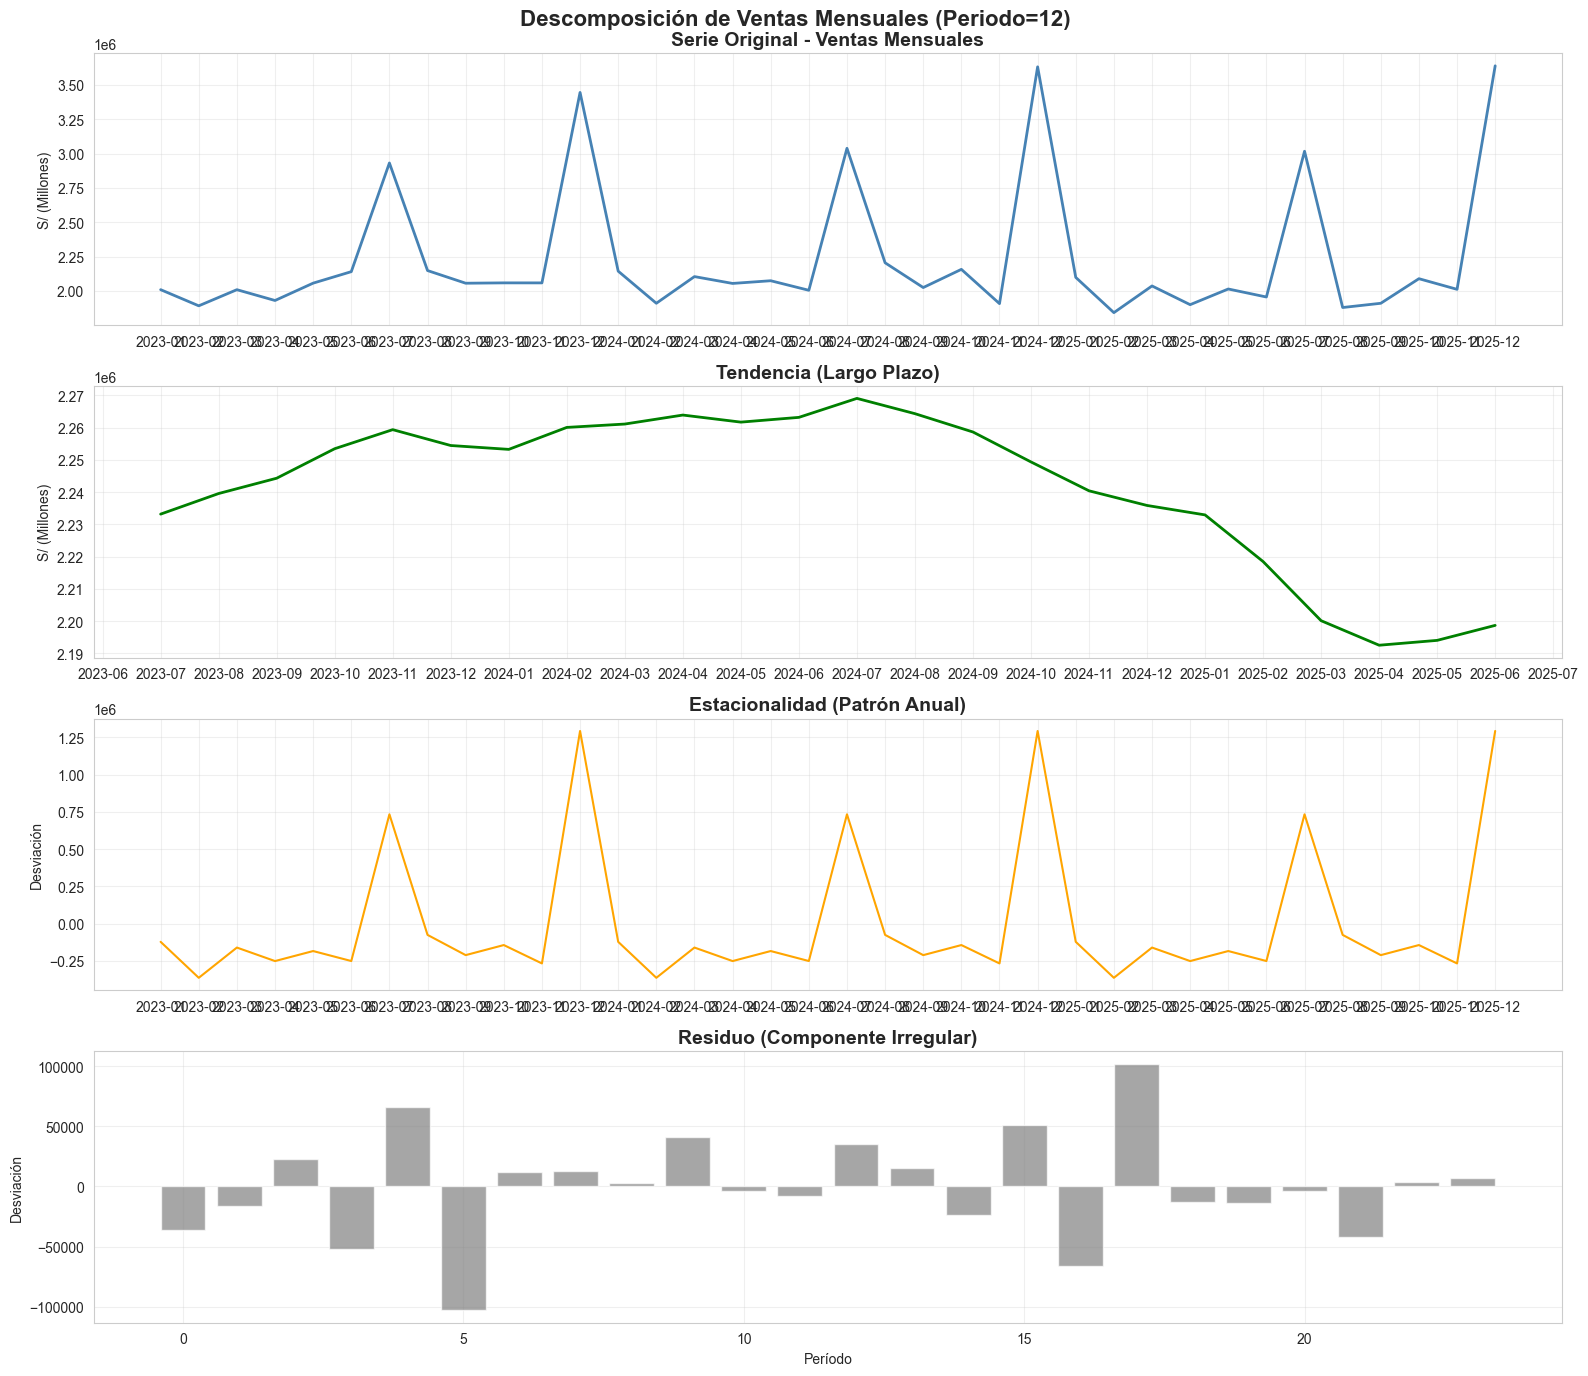

In [14]:
if 'df_mensual' in locals() and len(df_mensual) >= 24:
    print("=" * 70)
    print("📊 DESCOMPOSICIÓN DE SERIES TEMPORALES")
    print("=" * 70)
    
    # Preparar serie para descomposición
    serie_ventas = df_mensual.set_index('anio_mes')['ventas_totales']
    
    # Descomposición con periodo=12 (mensual)
    try:
        decomposition = seasonal_decompose(serie_ventas, model='additive', period=12)
        
        fig, axes = plt.subplots(4, 1, figsize=(16, 14))
        
        # Serie original
        axes[0].plot(serie_ventas.index, serie_ventas.values, color='steelblue', linewidth=2)
        axes[0].set_title('Serie Original - Ventas Mensuales', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('S/ (Millones)')
        axes[0].grid(True, alpha=0.3)
        
        # Tendencia
        axes[1].plot(serie_ventas.index, decomposition.trend, color='green', linewidth=2)
        axes[1].set_title('Tendencia (Largo Plazo)', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('S/ (Millones)')
        axes[1].grid(True, alpha=0.3)
        
        # Estacionalidad
        axes[2].plot(serie_ventas.index, decomposition.seasonal, color='orange', linewidth=1.5)
        axes[2].set_title('Estacionalidad (Patrón Anual)', fontsize=14, fontweight='bold')
        axes[2].set_ylabel('Desviación')
        axes[2].grid(True, alpha=0.3)
        
        # Residuo
        axes[3].bar(range(len(decomposition.resid.dropna())), 
                    decomposition.resid.dropna().values, color='gray', alpha=0.7)
        axes[3].set_title('Residuo (Componente Irregular)', fontsize=14, fontweight='bold')
        axes[3].set_ylabel('Desviación')
        axes[3].set_xlabel('Período')
        axes[3].grid(True, alpha=0.3)
        
        plt.suptitle('Descomposición de Ventas Mensuales (Periodo=12)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
    except Exception as e:
        print(f"⚠️ Error en descomposición: {e}")
        print("   Posible causa: datos insuficientes o valores nulos en la serie.")

else:
    print("⚠️ Se necesitan al menos 24 meses de datos para la descomposición estacional.")

### Interpretación de Negocio Resumida

*   **Tendencia (Largo Plazo) - 🚨 Alerta:** Crecimiento estable hasta mediados de 2024, seguido de una **caída sostenida**. Indica un problema estructural que requiere acción estratégica urgente para revertir el declive.

*   **Estacionalidad (Patrón Anual) - 📈 Oportunidad:** Picos muy marcados en **Julio y Diciembre**. Se deben aprovechar para planificar inventario y campañas, mientras que los valles son ideales para reducir costos y lanzar promociones.

*   **Residuo (Irregular) - ⚠️ Volatilidad:** Presencia de shocks externos atípicos (especialmente a finales de 2024). La creciente magnitud de los residuos sugiere que el negocio **se está volviendo más volátil e impredecible**; estos eventos deben investigarse.

# Autocorrelación (ACF)

📊 AUTOCORRELACIÓN (ACF)


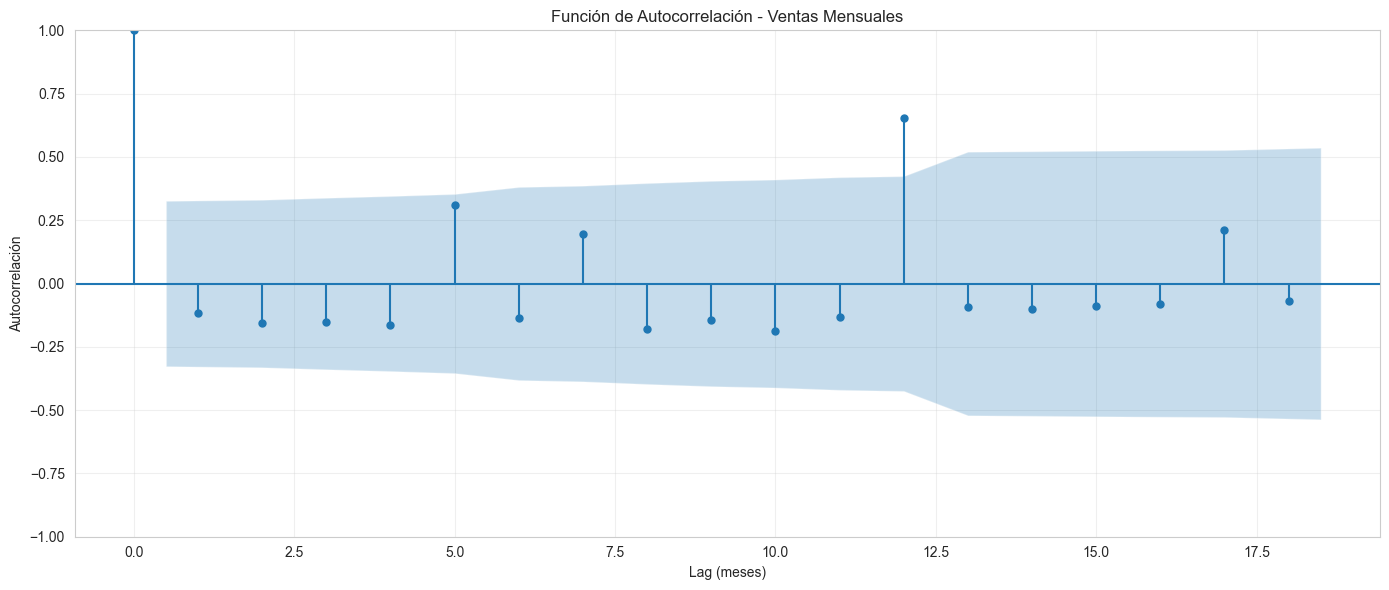

In [16]:
if 'serie_ventas' in locals():
    print("=" * 70)
    print("📊 AUTOCORRELACIÓN (ACF)")
    print("=" * 70)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    plot_acf(serie_ventas.dropna(), lags=min(24, len(serie_ventas)//2), ax=ax, 
             title='Función de Autocorrelación - Ventas Mensuales')
    ax.set_xlabel('Lag (meses)')
    ax.set_ylabel('Autocorrelación')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Interpretación de Negocio Resumida (ACF)

*   **Lag 12 (Valor 0.7) - Dominante:** Fuerte estacionalidad anual. **Acción:** Planificar inventario y campañas basándose en el mismo mes del año anterior.

*   **Lags 5, 7 y 17 (Valores ~0.23) - Débiles:** Apenas sobresalen del área de confianza. **Conclusión:** No representan patrones de negocio sólidos; se consideran ruido estadístico menor.

*   **Lag 1 (Sin pico) - Sin inercia:** No existe efecto de arrastre entre meses consecutivos. **Conclusión:** Las campañas no generan momentum al mes siguiente.

*   **Resumen ejecutivo:** El negocio es **altamente estacional (ciclo anual)** y carece de memoria de corto plazo. La estrategia comercial debe ser anual, no mensual.

# Análisis de Pareto

📊 ANÁLISIS DE PARETO - Regla 80/20

🔹 PARETO DE PRODUCTOS


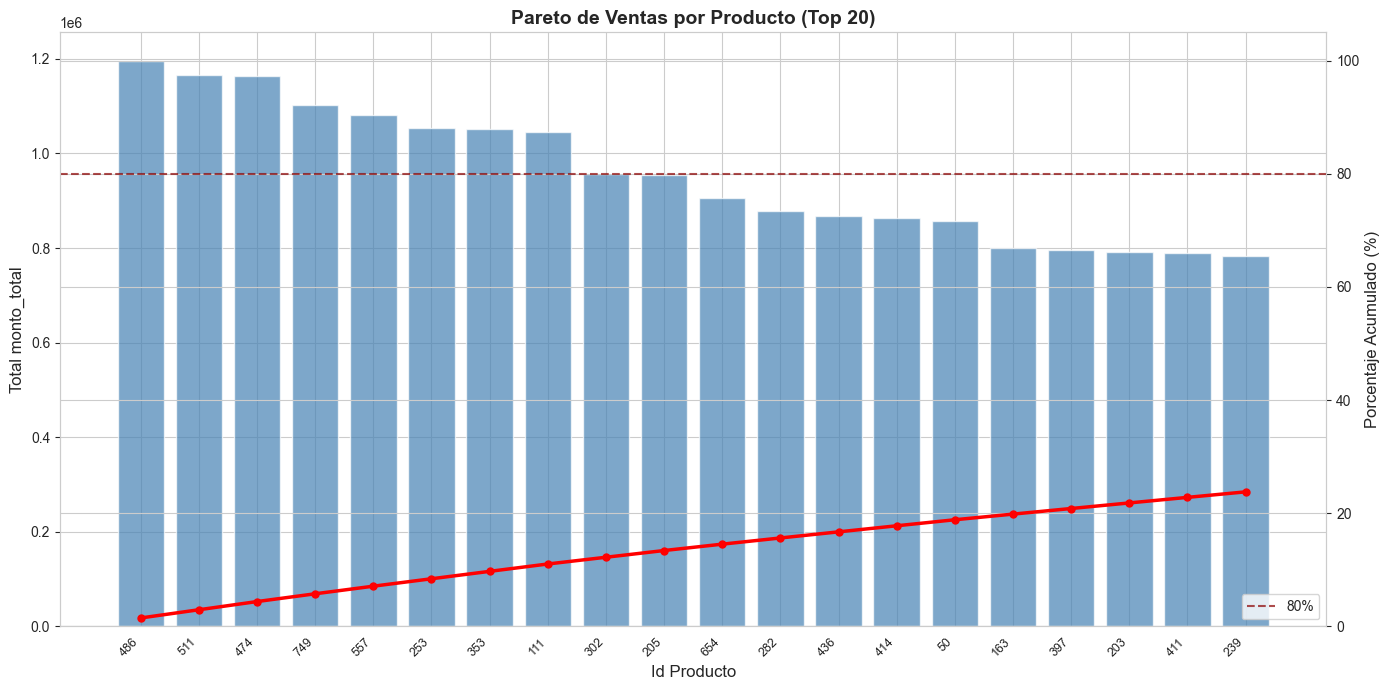


📌 146 productos (18.2% del total) generan el 80% de las ventas.
   Total productos: 800

🔹 PARETO DE CLIENTES


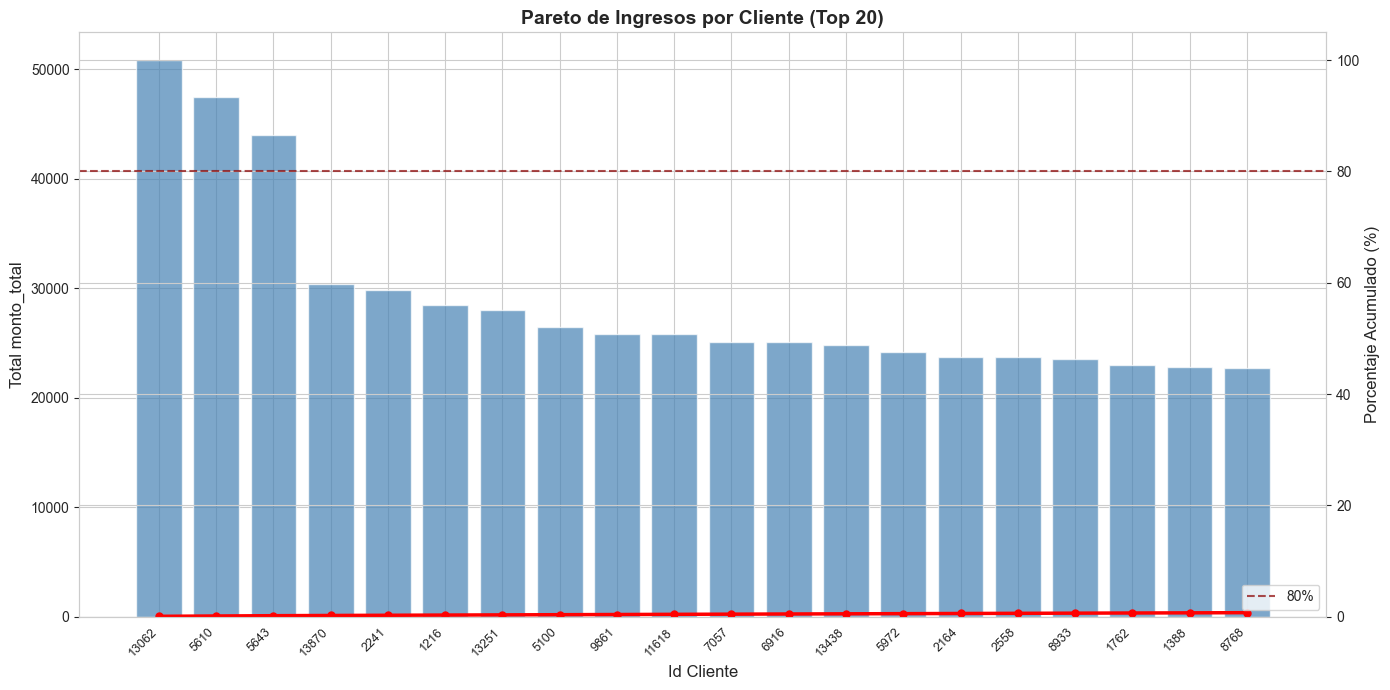


📌 8584 clientes (57.2% del total) generan el 80% de los ingresos.
   Total clientes: 15,000

🔹 PARETO DE CATEGORÍAS


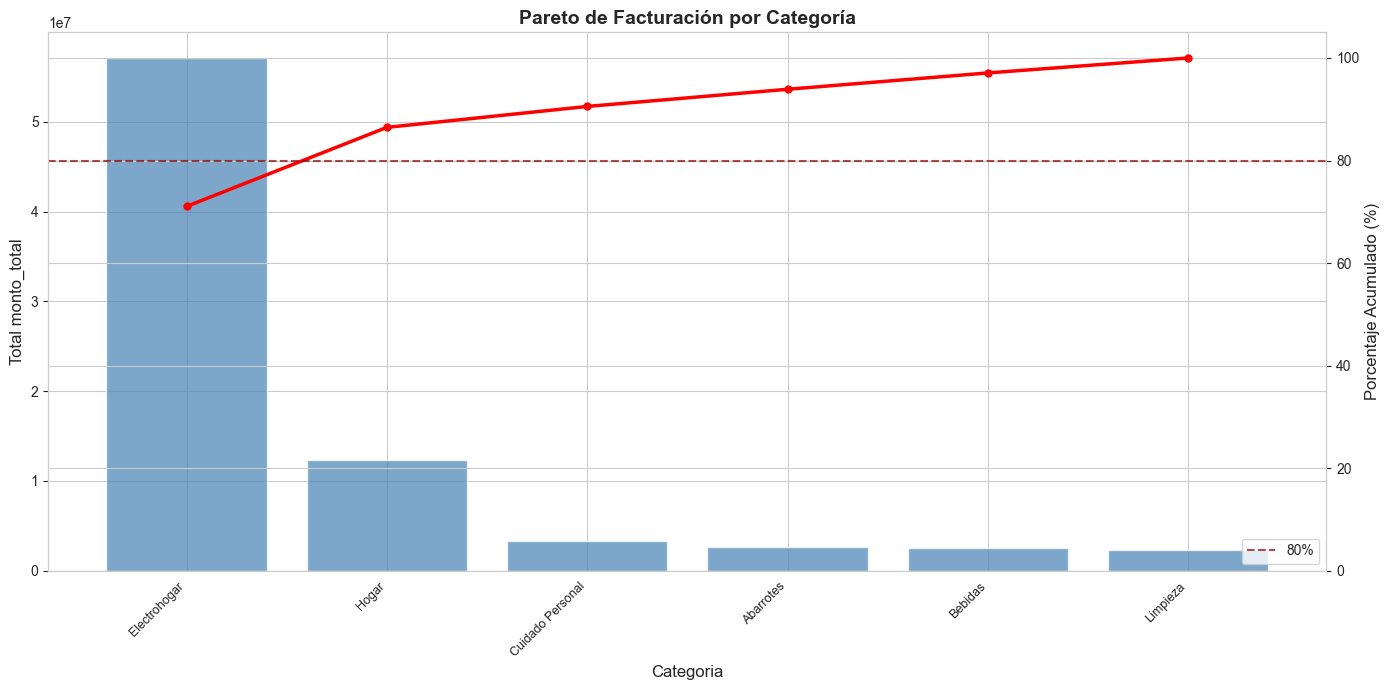


📌 2 categorías (33.3% del total) concentran el 80% de la facturación.


In [17]:
# ============================================================
# 5. ANÁLISIS DE PARETO (Regla 80/20)
# ============================================================

print("=" * 70)
print("📊 ANÁLISIS DE PARETO - Regla 80/20")
print("=" * 70)

def analisis_pareto(df, columna, valor, titulo, top_n=20):
    """
    Realiza análisis de Pareto para una dimensión de negocio.
    
    Parámetros:
    - df: DataFrame
    - columna: columna para agrupar (producto, cliente, categoría)
    - valor: columna de valor a sumar
    - titulo: título del gráfico
    - top_n: número de elementos a mostrar
    """
    # Agrupar y ordenar
    pareto = df.groupby(columna)[valor].sum().sort_values(ascending=False).reset_index()
    pareto.columns = [columna, 'total']
    
    # Calcular porcentajes
    total_general = pareto['total'].sum()
    pareto['porcentaje'] = (pareto['total'] / total_general) * 100
    pareto['acumulado'] = pareto['porcentaje'].cumsum()
    
    # Encontrar punto 80/20
    idx_80 = (pareto['acumulado'] >= 80).idxmax()
    n_80 = pareto.loc[:idx_80, columna].nunique()
    pct_80 = (n_80 / pareto[columna].nunique()) * 100
    
    # Mostrar top
    pareto_top = pareto.head(top_n)
    
    # Gráfico
    fig, ax1 = plt.subplots(figsize=(14, 7))
    
    # Barras
    bars = ax1.bar(range(len(pareto_top)), pareto_top['total'], color='steelblue', alpha=0.7)
    ax1.set_ylabel(f'Total {valor}', fontsize=12)
    ax1.set_xlabel(columna.replace('_', ' ').title(), fontsize=12)
    ax1.set_xticks(range(len(pareto_top)))
    ax1.set_xticklabels(pareto_top[columna], rotation=45, ha='right', fontsize=9)
    
    # Línea acumulada
    ax2 = ax1.twinx()
    ax2.plot(range(len(pareto_top)), pareto_top['acumulado'], color='red', linewidth=2.5, marker='o', markersize=5)
    ax2.axhline(y=80, color='darkred', linestyle='--', linewidth=1.5, alpha=0.7, label='80%')
    ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)
    ax2.set_ylim(0, 105)
    ax2.legend(loc='lower right')
    
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return pareto, n_80, pct_80

# === Pareto por Producto ===
print("\n🔹 PARETO DE PRODUCTOS")
pareto_prod, n_prod_80, pct_prod_80 = analisis_pareto(
    df, 'id_producto', 'monto_total', 
    'Pareto de Ventas por Producto (Top 20)'
)
print(f"\n📌 {n_prod_80} productos ({pct_prod_80:.1f}% del total) generan el 80% de las ventas.")
print(f"   Total productos: {pareto_prod['id_producto'].nunique():,}")

# === Pareto por Cliente ===
print("\n🔹 PARETO DE CLIENTES")
pareto_cliente, n_cli_80, pct_cli_80 = analisis_pareto(
    df, 'id_cliente', 'monto_total',
    'Pareto de Ingresos por Cliente (Top 20)'
)
print(f"\n📌 {n_cli_80} clientes ({pct_cli_80:.1f}% del total) generan el 80% de los ingresos.")
print(f"   Total clientes: {pareto_cliente['id_cliente'].nunique():,}")

# === Pareto por Categoría ===
if 'categoria' in df.columns:
    print("\n🔹 PARETO DE CATEGORÍAS")
    pareto_cat, n_cat_80, pct_cat_80 = analisis_pareto(
        df, 'categoria', 'monto_total',
        'Pareto de Facturación por Categoría'
    )
    print(f"\n📌 {n_cat_80} categorías ({pct_cat_80:.1f}% del total) concentran el 80% de la facturación.")

### Interpretación de Negocio: Análisis de Pareto (80/20)

#### 1. Productos (Top 20)
*   **Hallazgo:** **146 productos (18.2%)** generan el 80% de las ventas. El 81.8% restante (cola larga) solo aporta el 20%.
*   **Acción estratégica:**
    *   **Priorizar:** Asegurar stock y visibilidad en marketing para estos 146 productos estrella.
    *   **Revisar:** Analizar la rentabilidad de los 654 productos restantes. Evaluar si justifican el costo de almacenaje o si deben optimizarse/descontinuarse.

#### 2. Clientes (Top 20)
*   **Hallazgo:** **8,584 clientes (57.2%)** generan el 80% de los ingresos. **No se cumple el 80/20 estricto**; la base de clientes está muy diversificada y menos concentrada de lo habitual.
*   **Riesgo y Acción:**
    *   **Riesgo:** Aunque es un negocio sano por no depender de solo 4 o 5 personas, 8,584 clientes siguen siendo un grupo crítico (más de la mitad de la base).
    *   **Retención (VIP):** Crear un programa de fidelización exclusivo para los **Top 100/500** clientes para evitar su fuga.
    *   **Activación:** Para el 42.8% restante (que genera solo el 20%), desarrollar estrategias para aumentar su frecuencia de compra (ej. cupones post-compra, recordatorios).

#### 3. Categorías (Top 20)
*   **Hallazgo:** Solo **2 categorías (Electrohogar y Hogar)** representan el 80% de la facturación total. **Es una concentración extrema.**
*   **Acción estratégica:**
    *   **Espacio físico/digital:** Dar la mayor prioridad y espacio de exhibición a Electrohogar y Hogar en tienda y web.
    *   **Cruzadas:** Lanzar promociones cruzadas combinando Electrohogar/Hogar con categorías complementarias (ej. Descuentos en "Abarrotes" si compras un electrodoméstico).
    *   **Proveedores:** Negociar condiciones preferenciales (créditos, mejores precios) con los proveedores de estas 2 categorías, dado su peso crítico en el negocio.

**Resumen Ejecutivo:** El negocio depende en gran medida de **146 productos** y **2 categorías**. La base de clientes es algo diversa, pero los ingresos siguen siendo frágiles ante cualquier afectación en Electrohogar y Hogar.

# Análisis RFM - Cálculo

In [18]:
# ============================================================
# 6. ANÁLISIS RFM
# ============================================================

print("=" * 70)
print("📊 ANÁLISIS RFM (Recency, Frequency, Monetary)")
print("=" * 70)

# === Fecha de referencia ===
FECHA_REFERENCIA = pd.to_datetime('2025-12-31')
print(f"📅 Fecha de referencia: {FECHA_REFERENCIA.date()}")

# === Agrupar por cliente ===
rfm = df.groupby('id_cliente').agg(
    # Recency: días desde la última compra
    ultima_compra=('fecha', 'max'),
    # Frequency: número de transacciones
    frecuencia=('id_venta', 'count'),
    # Monetary: total gastado
    monetario=('monto_total', 'sum'),
    # Ticket promedio
    ticket_promedio=('monto_total', 'mean'),
    # Margen total
    margen_total=('margen', 'sum')
).reset_index()

# Calcular Recency
rfm['recency'] = (FECHA_REFERENCIA - rfm['ultima_compra']).dt.days

# Renombrar para claridad
rfm = rfm.rename(columns={'frecuencia': 'frequency', 'monetario': 'monetary'})

print(f"\n✅ RFM calculado para {len(rfm):,} clientes")
print(f"\n📊 Estadísticas RFM:")
print(f"   Recency (días):  min={rfm['recency'].min():.0f} | mediana={rfm['recency'].median():.0f} | max={rfm['recency'].max():.0f}")
print(f"   Frequency:       min={rfm['frequency'].min():.0f} | mediana={rfm['frequency'].median():.0f} | max={rfm['frequency'].max():.0f}")
print(f"   Monetary (S/.):  min=S/.{rfm['monetary'].min():,.0f} | mediana=S/.{rfm['monetary'].median():,.0f} | max=S/.{rfm['monetary'].max():,.0f}")

rfm.head()

📊 ANÁLISIS RFM (Recency, Frequency, Monetary)
📅 Fecha de referencia: 2025-12-31

✅ RFM calculado para 15,000 clientes

📊 Estadísticas RFM:
   Recency (días):  min=0 | mediana=27 | max=643
   Frequency:       min=3 | mediana=17 | max=33
   Monetary (S/.):  min=S/.213 | mediana=S/.4,662 | max=S/.50,824


,id_cliente,ultima_compra,frequency,monetary,ticket_promedio,margen_total,recency
0,1,2025-10-21,23,3343.23000,145.357826,1337.292000,71
1,2,2025-07-20,17,6373.38000,374.904706,2549.352000,164
2,3,2025-11-05,12,4347.21000,362.267500,1738.884000,56
3,4,2025-12-31,18,3401.33072,188.962818,1360.532288,0
4,5,2025-12-10,22,5559.19000,264.723333,2223.676000,21


# RFM - Puntajes y Segmentación

In [19]:
# === Asignar puntajes RFM (quintiles 1-5) ===
# Para Recency: menor es mejor (más reciente = mayor puntaje)
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])
# Para Frequency: mayor es mejor
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
# Para Monetary: mayor es mejor
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Crear código RFM
rfm['RFM_Score'] = (rfm['R_score'].astype(int).astype(str) + 
                     rfm['F_score'].astype(int).astype(str) + 
                     rfm['M_score'].astype(int).astype(str))

# Calcular score total
rfm['RFM_Total'] = rfm[['R_score', 'F_score', 'M_score']].astype(int).sum(axis=1)

# === Función de segmentación automática ===
def segmentar_rfm(row):
    """
    Clasifica clientes en segmentos basado en puntajes RFM.
    Reglas adaptadas para retail.
    """
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    total = r + f + m
    
    # Champions: alto en todo
    if total >= 13:
        return '🏆 Champions'
    # Leales: alta frecuencia
    elif f >= 4 and total >= 10:
        return '💎 Leales'
    # Potenciales: alto monetario, recency medio
    elif m >= 4 and r >= 3:
        return '🌟 Potenciales'
    # Prometedores: recency alto (recientes), frecuencia baja
    elif r >= 4 and f <= 2:
        return '🌱 Prometedores'
    # En riesgo: recency bajo, antes eran buenos
    elif r <= 2 and (f >= 3 or m >= 3):
        return '⚠️ En Riesgo'
    # Perdidos: recency muy bajo
    elif r <= 2 and f <= 2:
        return '❌ Perdidos'
    # Nuevos: recency alto, frecuencia muy baja
    elif r >= 4 and f == 1:
        return '🆕 Nuevos'
    # Dormidos: frecuencia baja, monetario bajo
    elif f <= 2 and m <= 2:
        return '💤 Dormidos'
    else:
        return '📦 Otros'

rfm['segmento'] = rfm.apply(segmentar_rfm, axis=1)

# === Resumen por segmento ===
print("=" * 70)
print("📊 RESUMEN DE SEGMENTOS RFM")
print("=" * 70)

resumen_rfm = rfm.groupby('segmento').agg(
    clientes=('id_cliente', 'count'),
    pct_clientes=('id_cliente', lambda x: round(len(x)/len(rfm)*100, 1)),
    recency_prom=('recency', 'mean'),
    frequency_prom=('frequency', 'mean'),
    monetary_prom=('monetary', 'mean'),
    ticket_prom=('ticket_promedio', 'mean'),
    margen_total=('margen_total', 'sum'),
    ingresos_totales=('monetary', 'sum'),
    pct_ingresos=('monetary', lambda x: round(x.sum()/rfm['monetary'].sum()*100, 1))
).sort_values('ingresos_totales', ascending=False)

print(resumen_rfm.round(1).to_string())

📊 RESUMEN DE SEGMENTOS RFM
                clientes  pct_clientes  recency_prom  frequency_prom  monetary_prom  ticket_prom  margen_total  ingresos_totales  pct_ingresos
segmento                                                                                                                                      
💎 Leales            3029          20.2          40.8            20.5         6315.3        311.6     7651650.5        19129126.2          23.8
⚠️ En Riesgo        3287          21.9         110.3            16.0         5370.0        360.4     7060489.1        17651222.6          22.0
🏆 Champions         1904          12.7           9.7            21.5         9263.3        440.5     7054955.9        17637389.8          21.9
🌟 Potenciales       1425           9.5          16.6            14.8         8009.0        552.1     4565106.2        11412765.5          14.2
📦 Otros             1591          10.6          18.4            16.6         3345.1        210.4     2128795.1     

# RFM - Visualización

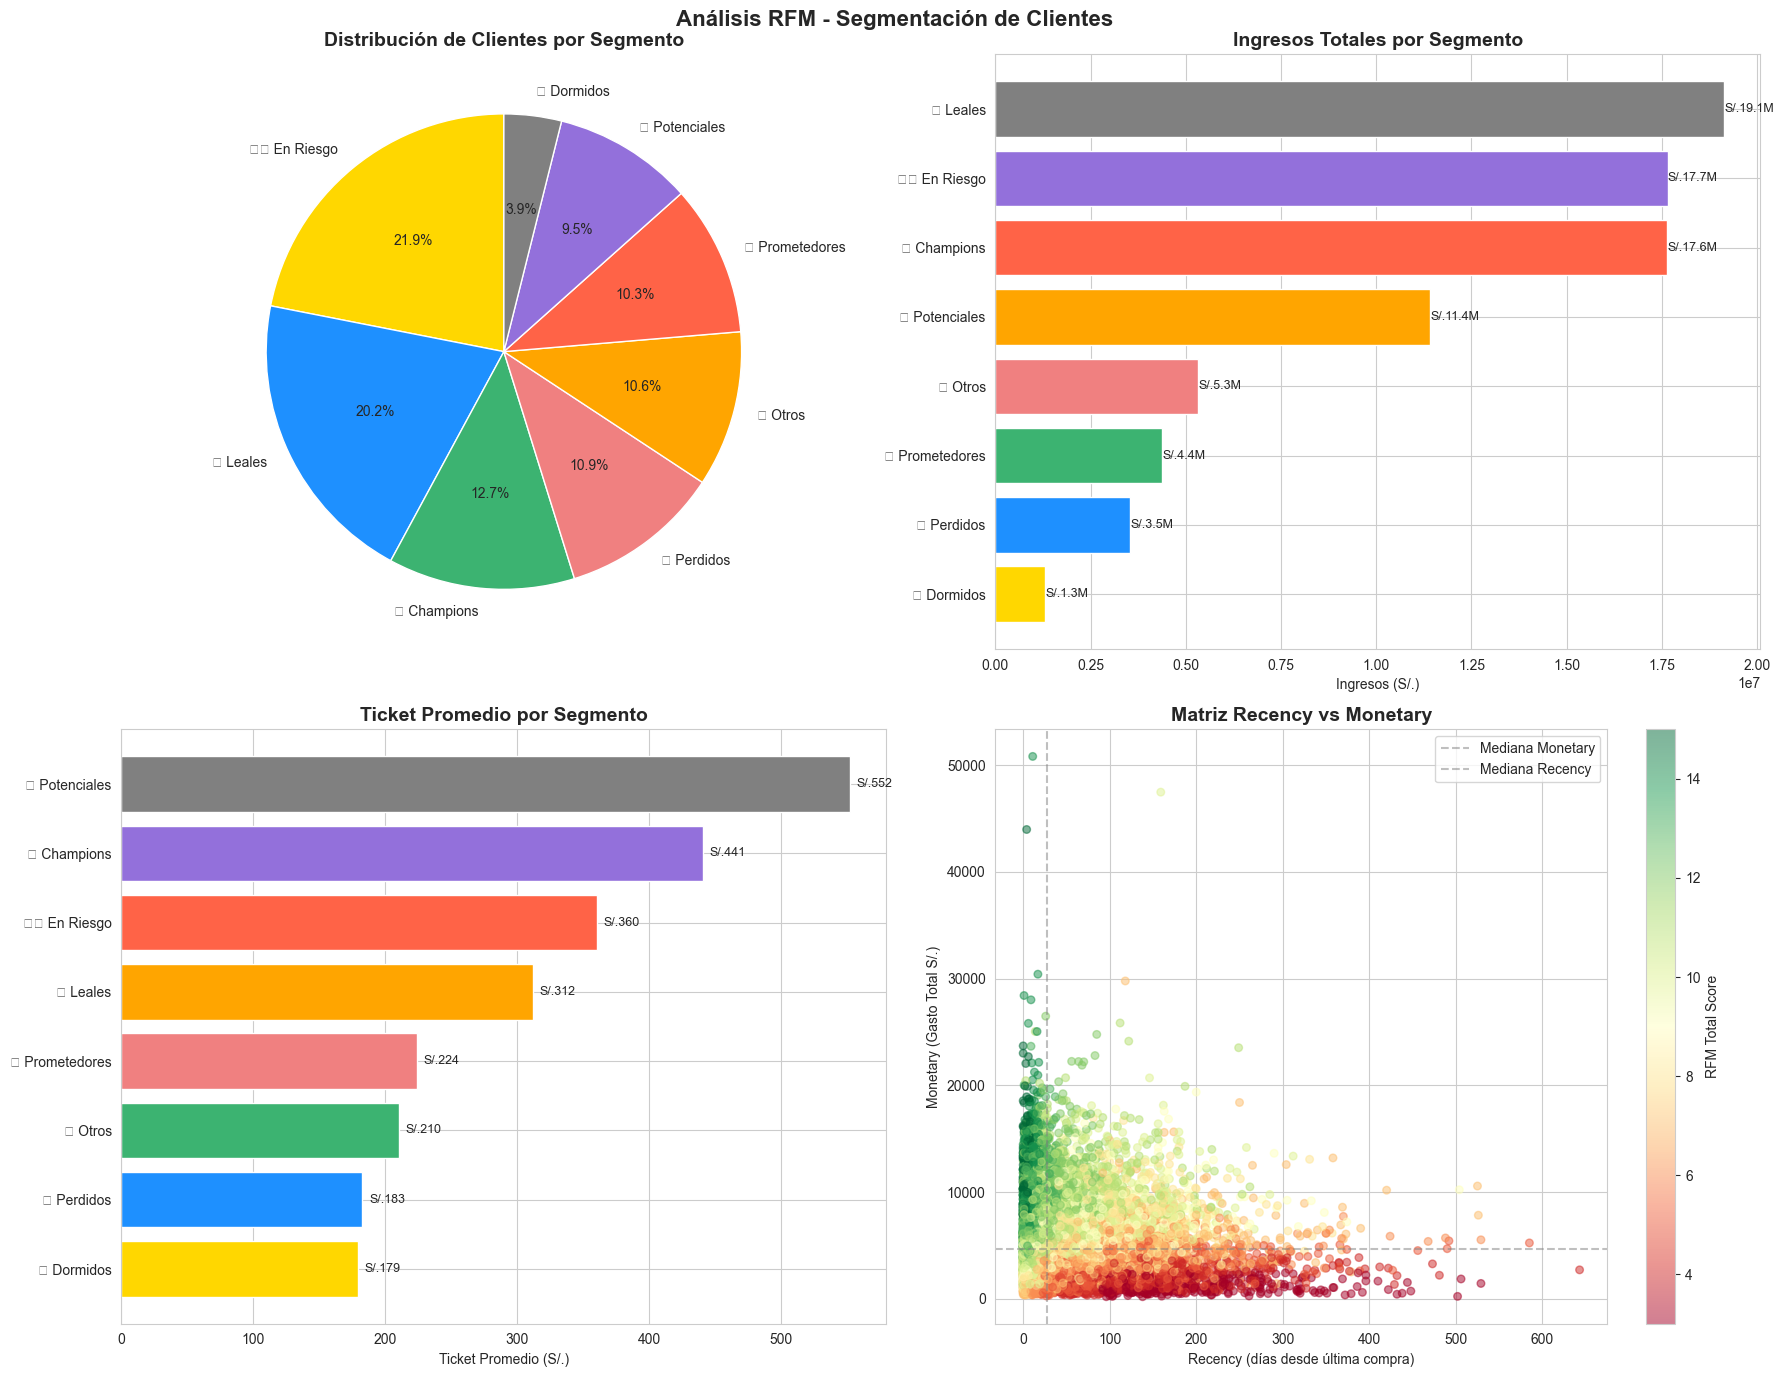

In [20]:
# === Visualización de segmentos RFM ===
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Distribución de segmentos (clientes)
segmentos_clientes = rfm['segmento'].value_counts()
colors = ['gold', 'dodgerblue', 'mediumseagreen', 'lightcoral', 
          'orange', 'tomato', 'mediumpurple', 'gray', 'lightblue']
axes[0, 0].pie(segmentos_clientes.values, labels=segmentos_clientes.index, 
               autopct='%1.1f%%', colors=colors[:len(segmentos_clientes)], startangle=90)
axes[0, 0].set_title('Distribución de Clientes por Segmento', fontsize=14, fontweight='bold')

# 2. Ingresos por segmento
ingresos_segmento = rfm.groupby('segmento')['monetary'].sum().sort_values(ascending=True)
bars = axes[0, 1].barh(ingresos_segmento.index, ingresos_segmento.values, 
                       color=colors[:len(ingresos_segmento)])
axes[0, 1].set_title('Ingresos Totales por Segmento', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Ingresos (S/.)')
for bar, val in zip(bars, ingresos_segmento.values):
    axes[0, 1].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, 
                    f'S/.{val/1e6:.1f}M', va='center', fontsize=9)

# 3. Ticket promedio por segmento
ticket_segmento = rfm.groupby('segmento')['ticket_promedio'].mean().sort_values()
bars = axes[1, 0].barh(ticket_segmento.index, ticket_segmento.values, 
                       color=colors[:len(ticket_segmento)])
axes[1, 0].set_title('Ticket Promedio por Segmento', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Ticket Promedio (S/.)')
for bar, val in zip(bars, ticket_segmento.values):
    axes[1, 0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
                    f'S/.{val:,.0f}', va='center', fontsize=9)

# 4. Matriz Recency vs Monetary
scatter = axes[1, 1].scatter(rfm['recency'], rfm['monetary'], 
                             c=rfm['RFM_Total'], cmap='RdYlGn', alpha=0.5, s=30)
axes[1, 1].set_xlabel('Recency (días desde última compra)')
axes[1, 1].set_ylabel('Monetary (Gasto Total S/.)')
axes[1, 1].set_title('Matriz Recency vs Monetary', fontsize=14, fontweight='bold')
axes[1, 1].axhline(y=rfm['monetary'].median(), color='gray', linestyle='--', alpha=0.5, label='Mediana Monetary')
axes[1, 1].axvline(x=rfm['recency'].median(), color='gray', linestyle='--', alpha=0.5, label='Mediana Recency')
axes[1, 1].legend()
plt.colorbar(scatter, ax=axes[1, 1], label='RFM Total Score')

plt.suptitle('Análisis RFM - Segmentación de Clientes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Análisis RFM - Segmentación de Clientes

### 🎯 Estrategia por Segmento

| Segmento | % Clientes | % Ingresos | Característica Clave | Estrategia Recomendada |
| :--- | :--- | :--- | :--- | :--- |
| 🏆 **Champions** | 12.7% | 21.9% | Alto gasto (S/9,263) y alta frecuencia | **VIP**: Acceso exclusivo, envío gratis y lanzamientos prioritarios. |
| 💎 **Leales** | 20.2% | 23.8% | Mayor frecuencia (20.5 compras) | **Fidelización**: Programa de puntos y up-selling para subirlos a Champions. |
| 🌟 **Potenciales** | 9.5% | 14.2% | Ticket más alto (S/552) | **Cross-selling**: Aumentar frecuencia sin depender de descuentos (ya gastan mucho). |
| ⚠️ **En Riesgo** | 21.9% | 22.0% | 110 días de inactividad | **Reactivación URGENTE**: Campaña "Te extrañamos" con oferta atractiva. |
| ❌ **Perdidos** | 10.9% | 4.4% | >126 días sin comprar | **Último intento**: Campaña agresiva; si no responden, descartar. |
| 🌱 **Prometedores** | 10.3% | 5.4% | Recientes (9.2 días desde última compra) | **Onboarding**: Email de bienvenida y descuento en segunda compra. |
| 💤 **Dormidos** | 3.9% | 1.6% | Bajo gasto y frecuencia | **Evaluar**: No son prioritarios si el costo de activación es alto. |
| 📦 **Otros** | 10.6% | 6.6% | Compra esporádica | **Incentivos**: Cupones por tiempo limitado para aumentar recompra. |

---

### 🚨 Diagnóstico de Negocio

- **Alerta Crítica de Retención:**
  - **Clientes en Riesgo + Perdidos representan el 32.8% de la base total.**
  - Estos segmentos generan el **26.4% de los ingresos**, pero están en riesgo de desaparecer.
  - **Acción prioritaria:** Lanzar campaña de reactivación masiva para el segmento **En Riesgo** antes de que migren a Perdidos.

- **Potencial de Crecimiento (Sin descuentos):**
  - El segmento **Potenciales** ya tiene el mejor ticket promedio (S/552). 
  - **Estrategia:** No ofrecer descuentos agresivos; enfocarse en cross-selling y recomendaciones personalizadas para aumentar su frecuencia.

- **Monitoreo de Adquisición:**
  - Los **Prometedores** (10.3% de la base) deben transicionar a Leales o Champions en los próximos 3 meses.
  - **KPI clave:** Si no migran, la estrategia de captación de nuevos clientes no es efectiva.

---

### 💰 Impacto en Ingresos

- **Champions + Leales:** Aportan el **45.7%** de los ingresos totales (por debajo del típico 60-70%). La base está más dispersa de lo normal.
- **En Riesgo + Perdidos:** Aportan el **26.4%** y representan una fuga de ingresos inminente si no se actúa.

# Clustering - Preparación

In [21]:
# ============================================================
# 7. CLUSTERING CON K-MEANS
# ============================================================

print("=" * 70)
print("📊 CLUSTERING DE CLIENTES (K-Means)")
print("=" * 70)

# === Seleccionar variables para clustering ===
X = rfm[['recency', 'frequency', 'monetary']].copy()

# === Estandarizar ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=['recency_scaled', 'frequency_scaled', 'monetary_scaled'])

print("✅ Datos estandarizados:")
print(f"   Media ≈ {X_scaled.mean().round(0).values}")
print(f"   Std ≈ {X_scaled.std().round(0).values}")

# === Determinar número óptimo de clusters ===
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

print(f"\n✅ Evaluación de clusters completada (K=2 a 10)")

📊 CLUSTERING DE CLIENTES (K-Means)
✅ Datos estandarizados:
   Media ≈ [0. 0. 0.]
   Std ≈ [1. 1. 1.]

✅ Evaluación de clusters completada (K=2 a 10)


# Clustering - Método del Codo y Silhouette

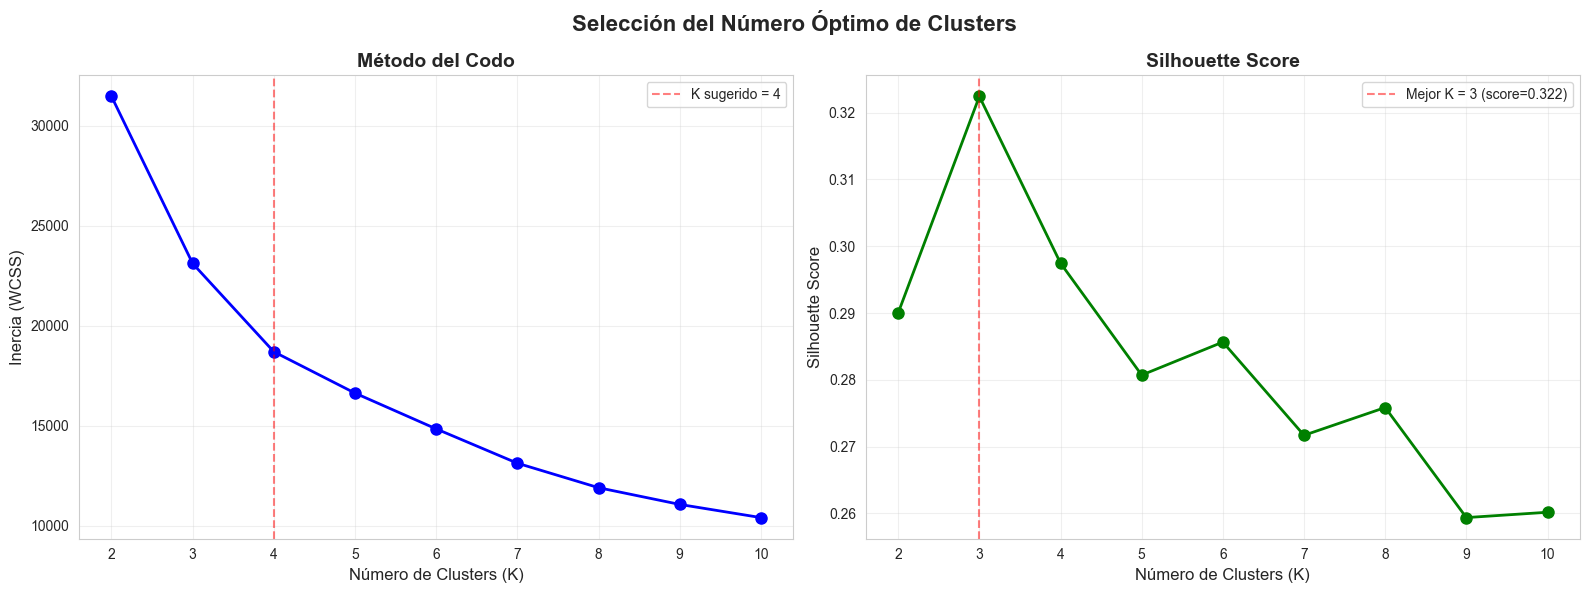

📌 Mejor K según Silhouette Score: 3 (score = 0.322)


In [22]:
# === Visualización: Método del Codo y Silhouette Score ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Método del Codo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=12)
axes[0].set_title('Método del Codo', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
# Marcar el codo sugerido
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.5, label='K sugerido = 4')
axes[0].legend()

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
# Marcar el mejor K
best_k = K_range[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.5, 
                label=f'Mejor K = {best_k} (score={max(silhouette_scores):.3f})')
axes[1].legend()

plt.suptitle('Selección del Número Óptimo de Clusters', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"📌 Mejor K según Silhouette Score: {best_k} (score = {max(silhouette_scores):.3f})")

# Clustering - Aplicación K-Means

In [23]:
# === Aplicar K-Means con el K óptimo ===
k_optimo = best_k  # Usar el mejor K encontrado

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

print(f"✅ Clustering completado con K={k_optimo}")
print(f"\n📊 Distribución de clientes por cluster:")
print(rfm['cluster'].value_counts().sort_index())

# === Centróides (en escala original) ===
centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=['recency', 'frequency', 'monetary']
)
centroides.index = [f'Cluster {i}' for i in range(k_optimo)]

print(f"\n📊 Características de cada cluster (centroides en escala original):")
print(centroides.round(1).to_string())

# === Estadísticas por cluster ===
resumen_cluster = rfm.groupby('cluster').agg(
    clientes=('id_cliente', 'count'),
    pct_clientes=('id_cliente', lambda x: round(len(x)/len(rfm)*100, 1)),
    recency_prom=('recency', 'mean'),
    frequency_prom=('frequency', 'mean'),
    monetary_prom=('monetary', 'mean'),
    ticket_prom=('ticket_promedio', 'mean'),
    ingresos_totales=('monetary', 'sum'),
    pct_ingresos=('monetary', lambda x: round(x.sum()/rfm['monetary'].sum()*100, 1))
).sort_values('monetary_prom', ascending=False)

print(f"\n📊 Resumen por Cluster:")
print(resumen_cluster.round(1).to_string())

✅ Clustering completado con K=3

📊 Distribución de clientes por cluster:
cluster
0    7627
1    5130
2    2243
Name: count, dtype: int64

📊 Características de cada cluster (centroides en escala original):
           recency  frequency  monetary
Cluster 0     31.1       14.9    3609.7
Cluster 1     33.0       20.3    8400.2
Cluster 2    173.8       14.2    4350.2

📊 Resumen por Cluster:
         clientes  pct_clientes  recency_prom  frequency_prom  monetary_prom  ticket_prom  ingresos_totales  pct_ingresos
cluster                                                                                                                  
1            5130          34.2          32.9            20.3         8400.1        432.5        43092489.1          53.6
2            2243          15.0         173.7            14.2         4351.4        313.9         9760101.8          12.1
0            7627          50.8          31.1            14.9         3607.8        251.1        27516431.8          34.2


# Clustering - Visualización

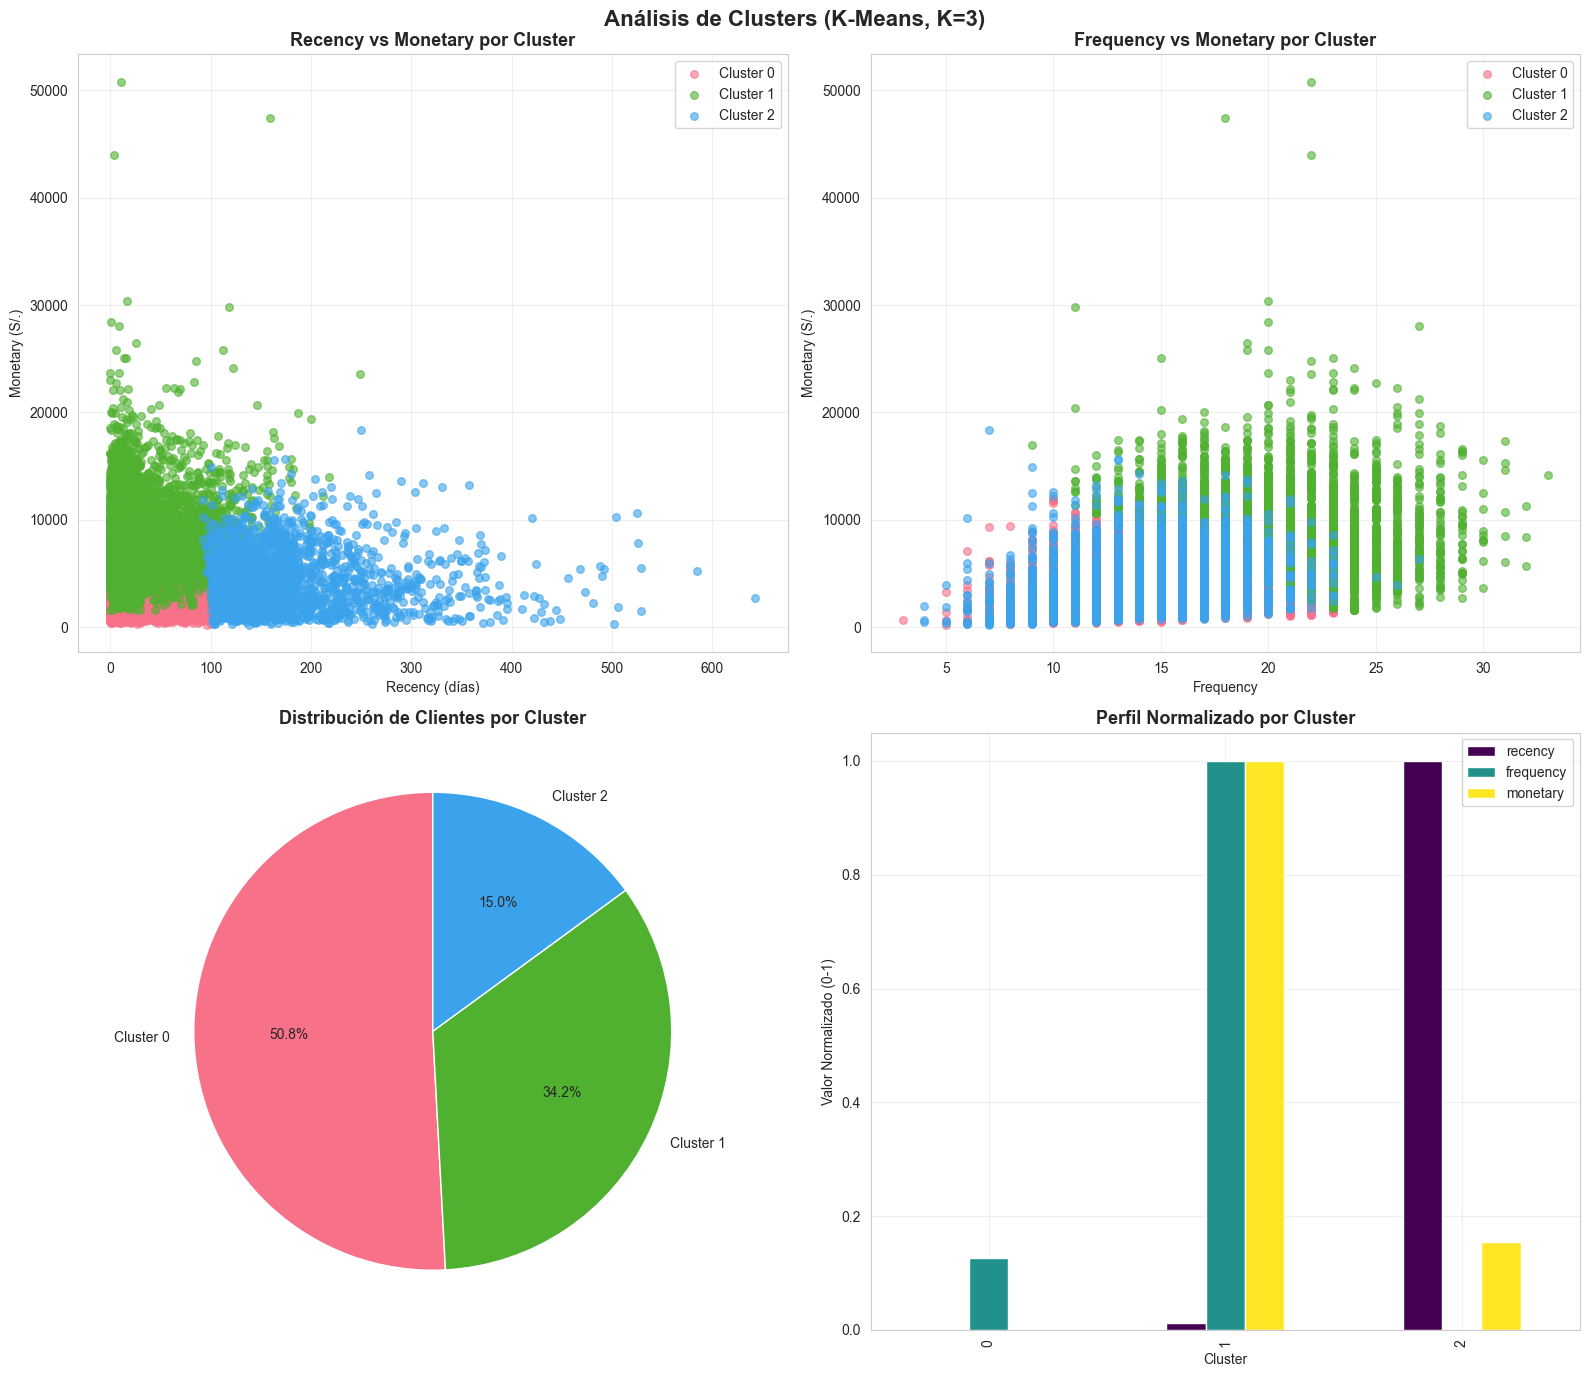

In [24]:
# === Visualización de clusters ===
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

palette = sns.color_palette("husl", k_optimo)

# 1. Scatter: Recency vs Monetary
for i in range(k_optimo):
    mask = rfm['cluster'] == i
    axes[0, 0].scatter(rfm.loc[mask, 'recency'], rfm.loc[mask, 'monetary'], 
                       c=[palette[i]], label=f'Cluster {i}', alpha=0.6, s=30)
axes[0, 0].set_xlabel('Recency (días)')
axes[0, 0].set_ylabel('Monetary (S/.)')
axes[0, 0].set_title('Recency vs Monetary por Cluster', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Scatter: Frequency vs Monetary
for i in range(k_optimo):
    mask = rfm['cluster'] == i
    axes[0, 1].scatter(rfm.loc[mask, 'frequency'], rfm.loc[mask, 'monetary'], 
                       c=[palette[i]], label=f'Cluster {i}', alpha=0.6, s=30)
axes[0, 1].set_xlabel('Frequency')
axes[0, 1].set_ylabel('Monetary (S/.)')
axes[0, 1].set_title('Frequency vs Monetary por Cluster', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Tamaño de clusters (pie chart)
cluster_counts = rfm['cluster'].value_counts().sort_index()
axes[1, 0].pie(cluster_counts.values, labels=[f'Cluster {i}' for i in cluster_counts.index], 
               autopct='%1.1f%%', colors=palette, startangle=90)
axes[1, 0].set_title('Distribución de Clientes por Cluster', fontsize=13, fontweight='bold')

# 4. Barras: Valor promedio por cluster
cluster_avg = rfm.groupby('cluster')[['recency', 'frequency', 'monetary']].mean()
cluster_avg_norm = (cluster_avg - cluster_avg.min()) / (cluster_avg.max() - cluster_avg.min())
cluster_avg_norm.plot(kind='bar', ax=axes[1, 1], colormap='viridis')
axes[1, 1].set_title('Perfil Normalizado por Cluster', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Valor Normalizado (0-1)')
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Análisis de Clusters (K-Means, K={k_optimo})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Análisis de Clusters (K-Means, K=3) - Interpretación de Negocio

### 📌 Distribución y Caracterización de Clusters

| Cluster | % Clientes | % Ingresos | Perfil Típico (Datos Reales) | Estrategia Recomendada |
| :--- | :--- | :--- | :--- | :--- |
| **Cluster 1**<br>(Alto Valor - Verde) | **34.2%** | **53.6%** | **Frecuentes y Gran Gasto.** Recency bajo (33 días), frecuencia muy alta (20.3 compras) y monetary elevado (**S/8,400**). Ticket promedio de S/432. | **Programa VIP y Retención.** Son el motor del negocio. Ofrecer atención personalizada, envío gratis y acceso anticipado a ofertas. |
| **Cluster 0**<br>(Regulares - Rosa) | **50.8%** | **34.2%** | **Base Masiva y Recurrente.** Recency bajo (31 días), frecuencia moderada (14.9 compras) y monetary bajo (**S/3,607**). Ticket promedio de S/251. | **Fidelización y Up-selling.** Programa de puntos para aumentar su frecuencia y ticket. Son el grupo con mayor potencial de crecimiento. |
| **Cluster 2**<br>(Inactivos - Azul) | **15.0%** | **12.1%** | **Abandonados.** Recency **extremadamente alto (174 días)**. Frecuencia (14.2) y monetary (S/4,351) moderados. | **Reactivación Urgente.** Han dejado de comprar por casi 6 meses. Lanzar campaña de reactivación agresiva (descuentos atractivos o encuestas de satisfacción). |

---

### 🚨 Acción Inmediata: Cruce RFM vs Clusters

> **💡 Insight Clave:** El Cluster 2 (Inactivos) representa el **15% de la base** y todavía genera el **12.1% de los ingresos**. Es una fuga de dinero que debe detenerse.

- **Prioridad Máxima (Cruce RFM):**
  - Identificar a los clientes del **Cluster 1 (Alto Valor)** que pertenecen al segmento RFM **⚠️ "En Riesgo"** o **❌ "Perdidos"**.
  - **Acción:** Contactarlos de forma **inmediata y personalizada**. Son los clientes más valiosos que estás a punto de perder. Ofrecerles una oferta exclusiva para recuperarlos.

- **Estrategia para el Cluster 0 (Base Masiva):**
  - Este grupo compra seguido pero gasta poco. Se debe implementar una estrategia de **Up-selling** (ofrecer productos de mayor valor) y **Cross-selling** para elevar su monetary promedio.

- **Estrategia para el Cluster 2 (Inactivos):**
  - Evaluar el costo de reactivación. Si el ticket promedio (S/313) no justifica una campaña costosa, optar por **email automation** de bajo costo antes de descartarlos definitivamente.

# PCA

📊 ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
✅ Varianza explicada por componente:
   PC1: 49.3%
   PC2: 30.9%
   Total: 80.2%


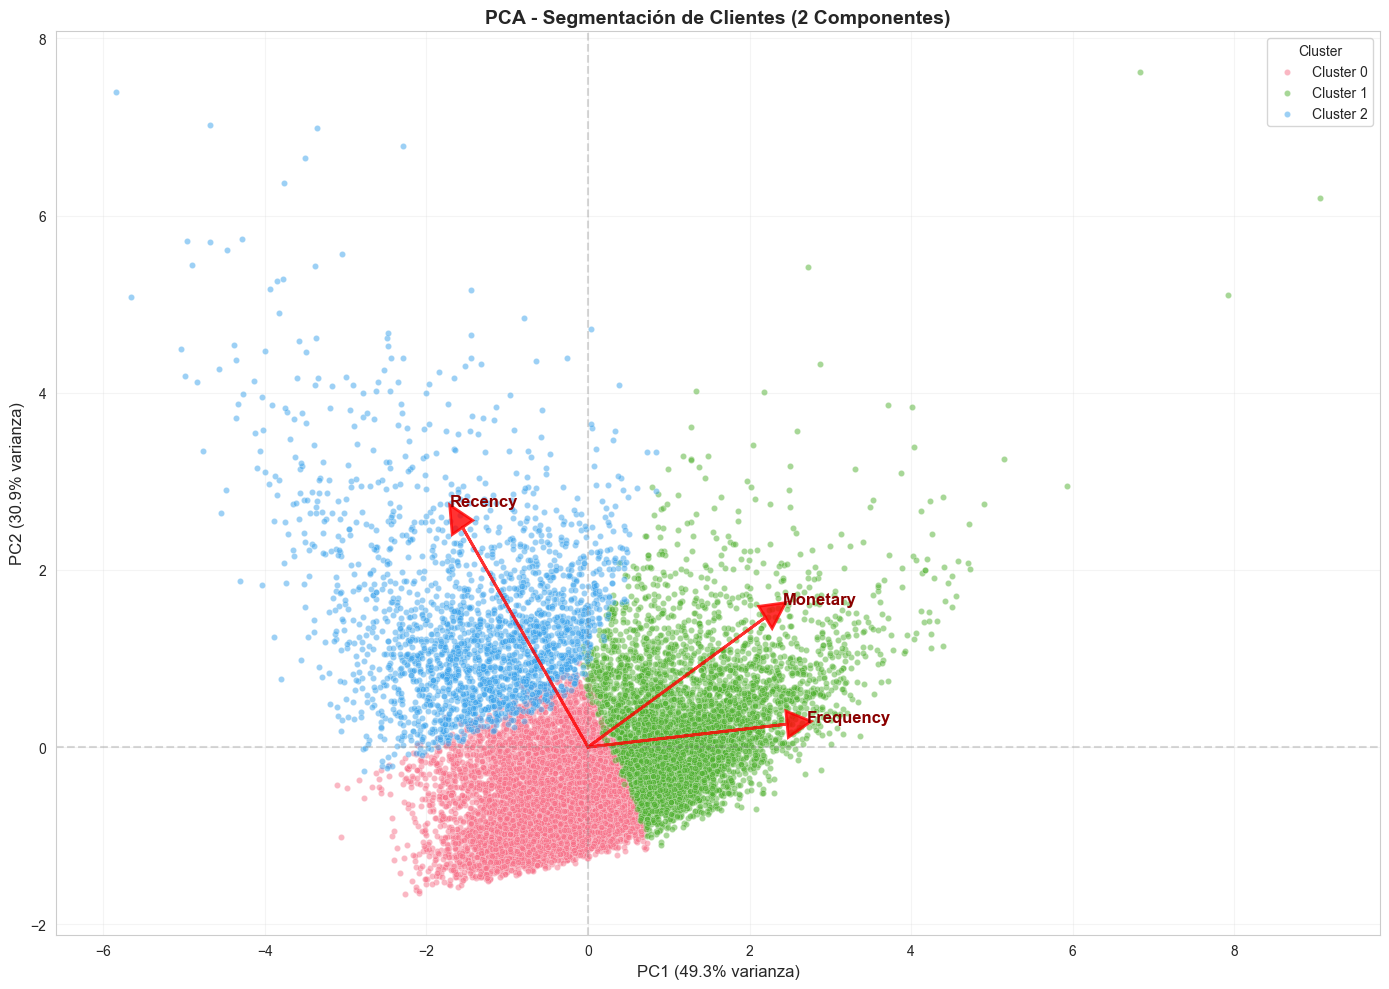

In [26]:
# ============================================================
# 8. ANÁLISIS PCA
# ============================================================

print("=" * 70)
print("📊 ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("=" * 70)

# === Aplicar PCA ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
print(f"✅ Varianza explicada por componente:")
print(f"   PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"   PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"   Total: {pca.explained_variance_ratio_.sum():.1%}")

# Crear DataFrame con resultados PCA
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = rfm['cluster'].values

# === Scatter Plot PCA con clusters ===
fig, ax = plt.subplots(figsize=(14, 10))

for i in range(k_optimo):
    mask = df_pca['cluster'] == i
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'], 
               c=[palette[i]], label=f'Cluster {i}', alpha=0.5, s=20, edgecolors='white', linewidth=0.3)

# Agregar vectores de carga (loadings)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
features = ['Recency', 'Frequency', 'Monetary']
for i, feature in enumerate(features):
    ax.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, 
             head_width=0.3, head_length=0.3, fc='red', ec='red', alpha=0.8, linewidth=2)
    ax.text(loadings[i, 0]*3.3, loadings[i, 1]*3.3, feature, 
            fontsize=12, fontweight='bold', color='darkred')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=12)
ax.set_title('PCA - Segmentación de Clientes (2 Componentes)', fontsize=14, fontweight='bold')
ax.legend(title='Cluster', loc='upper right')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 📊 Interpretación PCA (Resumida)

### 🔍 Varianza Explicada
*   **PC1 (49.3%) + PC2 (30.9%) = 80.2%.** Los 2 componentes representan fielmente la información del dataset.

### 🎯 Vectores Rojos (Loadings)
*   **Monetary y Frequency:** Apuntan juntos a la derecha. Indican **correlación positiva fuerte**: los que más gastan son los que más compran.
*   **Recency:** Apunta hacia arriba y a la izquierda (sentido opuesto). **Correlación negativa** con el gasto y la frecuencia.
*   **Longitud:** Los 3 vectores tienen peso **equilibrado**; ninguna variable domina el modelo.

### 🟢 Separación de Clusters
*   **Cluster 1 (Verde - Alto Valor):** Se extiende hacia la derecha. Agrupa clientes con **alto Monetary y alta Frequency**.
*   **Cluster 0 (Rosa - Regulares):** Concentrado abajo a la izquierda. Clientes con **baja Recency** (recientes), pero bajo gasto y frecuencia moderada.
*   **Cluster 2 (Azul - Inactivos):** Se desplaza hacia arriba. Clientes con **alta Recency** (muchos días sin comprar).
*   **Superposición:** Ligera zona de contacto entre Rosa y Verde. Existen clientes con **comportamientos híbridos** entre ambos grupos.

# Análisis Diagnóstico del Margen

🔍 ANÁLISIS DIAGNÓSTICO - CAÍDA DEL MARGEN

📊 MARGEN PROMEDIO POR CIUDAD
----------------------------------------
               ventas  margen_total  margen_pct  ticket_prom  descuento_prom  precio_prom
ciudad                                                                                   
Arequipa  11560609.96    4624243.98        40.0       321.99           12.06       236.28
Cusco     11595103.34    4638041.34        40.0       323.68           12.09       237.79
Lima      23173920.39    9269568.15        40.0       325.11           12.10       236.48
Piura     23011233.05    9204493.22        40.0       325.75           12.17       239.33
Trujillo  11028155.96    4411262.39        40.0       307.95           14.95       234.46


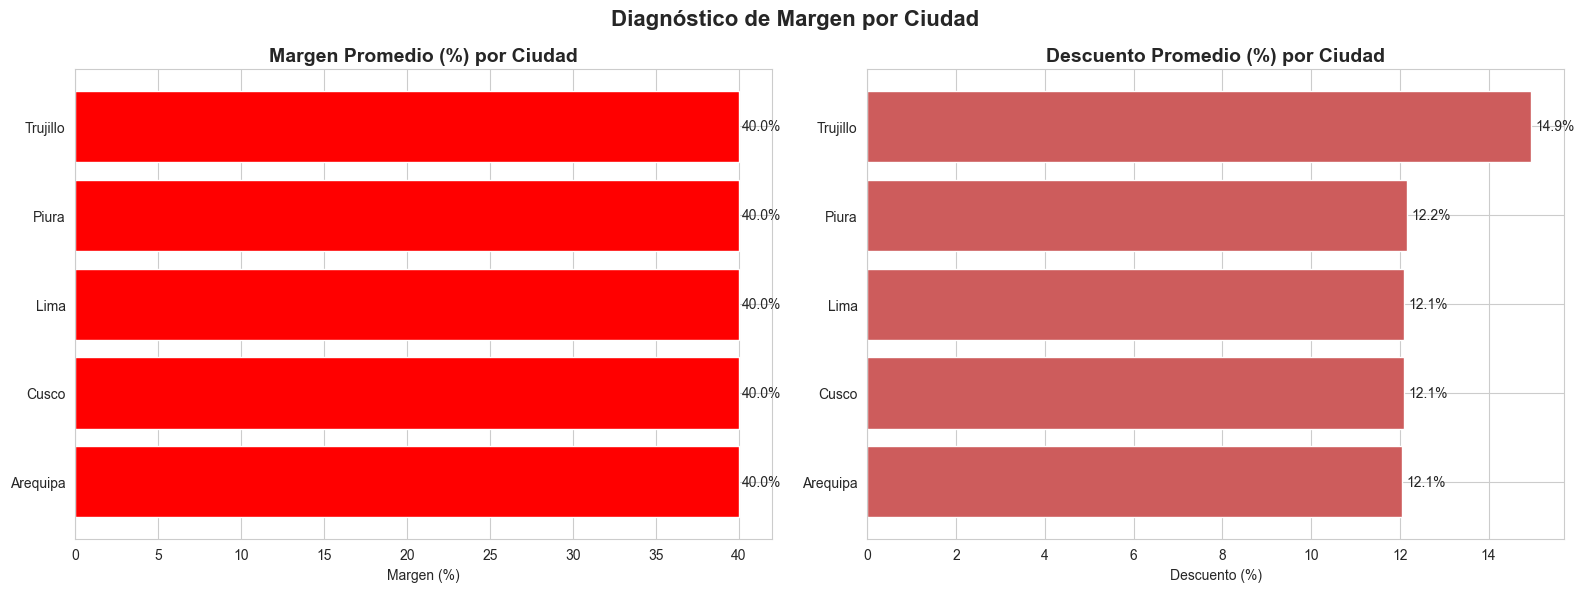


🔴 Ciudad con menor margen: Arequipa (40.0%)
   Descuento promedio: 12.1%
   Ticket promedio: S/.321.99


In [27]:
# ============================================================
# 9. ANÁLISIS DIAGNÓSTICO DEL MARGEN
# ============================================================

print("=" * 70)
print("🔍 ANÁLISIS DIAGNÓSTICO - CAÍDA DEL MARGEN")
print("=" * 70)

# === 1. Margen por ciudad ===
print("\n📊 MARGEN PROMEDIO POR CIUDAD")
print("-" * 40)
margen_ciudad = df.groupby('ciudad').agg(
    ventas=('monto_total', 'sum'),
    margen_total=('margen', 'sum'),
    margen_pct=('margen_pct', 'mean'),
    ticket_prom=('monto_total', 'mean'),
    descuento_prom=('descuento', 'mean'),
    precio_prom=('precio_unitario', 'mean')
).round(2).sort_values('margen_pct')

print(margen_ciudad.to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Margen % por ciudad
colors_ciudad = ['red' if x == margen_ciudad['margen_pct'].min() else 'steelblue' for x in margen_ciudad['margen_pct']]
axes[0].barh(margen_ciudad.index, margen_ciudad['margen_pct'], color=colors_ciudad)
axes[0].set_title('Margen Promedio (%) por Ciudad', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Margen (%)')
for i, (ciudad, row) in enumerate(margen_ciudad.iterrows()):
    axes[0].text(row['margen_pct'] + 0.2, i, f"{row['margen_pct']:.1f}%", va='center')

# Descuento promedio por ciudad
axes[1].barh(margen_ciudad.index, margen_ciudad['descuento_prom'], color='indianred')
axes[1].set_title('Descuento Promedio (%) por Ciudad', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Descuento (%)')
for i, (ciudad, row) in enumerate(margen_ciudad.iterrows()):
    axes[1].text(row['descuento_prom'] + 0.1, i, f"{row['descuento_prom']:.1f}%", va='center')

plt.suptitle('Diagnóstico de Margen por Ciudad', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar ciudad con menor margen
ciudad_problema = margen_ciudad['margen_pct'].idxmin()
print(f"\n🔴 Ciudad con menor margen: {ciudad_problema} ({margen_ciudad.loc[ciudad_problema, 'margen_pct']:.1f}%)")
print(f"   Descuento promedio: {margen_ciudad.loc[ciudad_problema, 'descuento_prom']:.1f}%")
print(f"   Ticket promedio: S/.{margen_ciudad.loc[ciudad_problema, 'ticket_prom']:,.2f}")

# Diagnóstico - Drill-down Temporal


📊 EVOLUCIÓN TEMPORAL DEL MARGEN
----------------------------------------


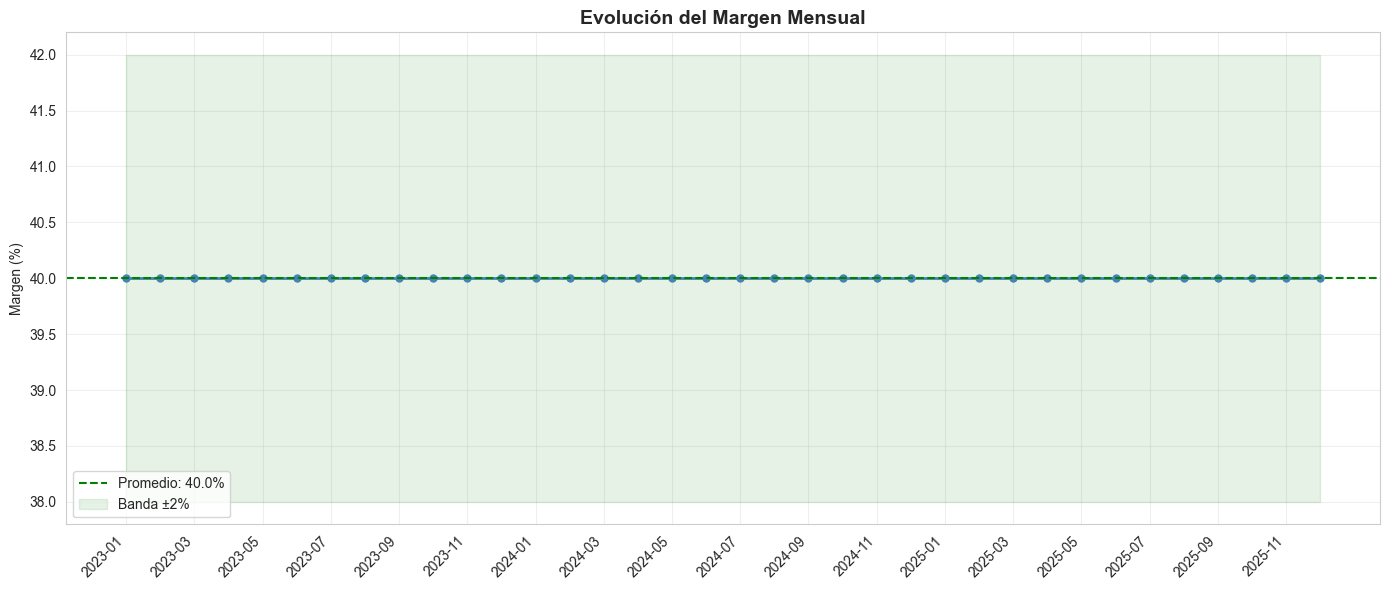

In [28]:
# === 2. Margen en el tiempo (mensual) ===
print("\n📊 EVOLUCIÓN TEMPORAL DEL MARGEN")
print("-" * 40)

if 'df_mensual' in locals():
    # Identificar punto de caída
    margen_promedio = df_mensual['margen_pct'].mean()
    df_mensual['margen_caida'] = df_mensual['margen_pct'] < (margen_promedio - 2)
    
    # Mostrar meses con margen bajo
    meses_caida = df_mensual[df_mensual['margen_caida']]
    if len(meses_caida) > 0:
        print(f"\n🔴 Meses con margen por debajo del promedio ({margen_promedio:.1f}% - 2%):")
        print(meses_caida[['anio_mes', 'margen_pct', 'ticket_promedio', 'num_transacciones']].to_string())
    
    # Gráfico de evolución
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(df_mensual['anio_mes'], df_mensual['margen_pct'], 
            color='steelblue', linewidth=2, marker='o', markersize=5)
    ax.axhline(y=margen_promedio, color='green', linestyle='--', 
               label=f'Promedio: {margen_promedio:.1f}%')
    ax.fill_between(range(len(df_mensual)), margen_promedio - 2, margen_promedio + 2, 
                     color='green', alpha=0.1, label='Banda ±2%')
    # Marcar puntos de caída
    for idx in meses_caida.index:
        ax.scatter(df_mensual.index.get_loc(idx), df_mensual.loc[idx, 'margen_pct'], 
                   color='red', s=80, zorder=5)
    ax.set_title('Evolución del Margen Mensual', fontsize=14, fontweight='bold')
    ax.set_ylabel('Margen (%)')
    ax.set_xticks(range(0, len(df_mensual), 2))
    ax.set_xticklabels(df_mensual['anio_mes'].iloc[::2], rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Diagnóstico - Comparativa Antes/Después

In [29]:
# === 3. Comparativa: Antes vs Después de 2025-Q2 ===
print("\n📊 COMPARATIVA: ANTES vs DESPUÉS DE 2025-Q2")
print("-" * 40)

# Crear bandera de período
df['periodo'] = np.where(df['fecha'] < '2025-04-01', 'Antes 2025-Q2', 'Después 2025-Q2')

# Comparativa general
comparativa = df.groupby('periodo').agg(
    transacciones=('id_venta', 'count'),
    ventas_totales=('monto_total', 'sum'),
    ticket_prom=('monto_total', 'mean'),
    margen_pct=('margen_pct', 'mean'),
    descuento_prom=('descuento', 'mean'),
    precio_prom=('precio_unitario', 'mean'),
    cantidad_prom=('cantidad', 'mean')
).round(2)

print(comparativa.to_string())

# Calcular variaciones
print("\n📊 VARIACIONES (Después vs Antes):")
for col in comparativa.columns:
    antes = comparativa.loc['Antes 2025-Q2', col]
    despues = comparativa.loc['Después 2025-Q2', col]
    var = ((despues - antes) / antes) * 100
    direccion = '🔴' if var < 0 else '🟢'
    print(f"   {col}: {direccion} {var:+.1f}%")

# === 4. Drill-down: Trujillo (ciudad problema) ===
if ciudad_problema in df['ciudad'].values:
    print(f"\n📊 DRILL-DOWN: {ciudad_problema.upper()}")
    print("-" * 40)
    
    df_ciudad = df[df['ciudad'] == ciudad_problema]
    
    # Por período
    comp_ciudad = df_ciudad.groupby('periodo').agg(
        ventas=('monto_total', 'sum'),
        margen_pct=('margen_pct', 'mean'),
        descuento=('descuento', 'mean'),
        precio=('precio_unitario', 'mean')
    ).round(2)
    print(comp_ciudad.to_string())
    
    # Por categoría en la ciudad problema
    comp_cat_ciudad = df_ciudad.groupby(['periodo', 'categoria'])['margen_pct'].mean().unstack()
    print(f"\n📊 Margen por Categoría en {ciudad_problema} por Período:")
    print(comp_cat_ciudad.round(1).to_string())


📊 COMPARATIVA: ANTES vs DESPUÉS DE 2025-Q2
----------------------------------------
                 transacciones  ventas_totales  ticket_prom  margen_pct  descuento_prom  precio_prom  cantidad_prom
periodo                                                                                                            
Antes 2025-Q2           185041     59956763.69       324.90        40.0           12.04       238.07           2.30
Después 2025-Q2          65096     20412259.01       314.42        40.0           13.87       234.57           2.29

📊 VARIACIONES (Después vs Antes):
   transacciones: 🔴 -64.8%
   ventas_totales: 🔴 -66.0%
   ticket_prom: 🔴 -3.2%
   margen_pct: 🟢 +0.0%
   descuento_prom: 🟢 +15.2%
   precio_prom: 🔴 -1.5%
   cantidad_prom: 🔴 -0.4%

📊 DRILL-DOWN: AREQUIPA
----------------------------------------
                     ventas  margen_pct  descuento  precio
periodo                                                   
Antes 2025-Q2    8882397.95        40.0      12.01  2

## 🔍 Diagnóstico: ¿Qué explica la caída del margen?

### 1. Factor Precio-Descuento (Principal Sospechoso)
*   **Datos:** El descuento promedio subió de **12.04% a 13.87%** (+15.2%) después de 2025-Q2.
*   **Anomalía:** Trujillo tiene el descuento más alto (**14.9%**) vs el resto de ciudades (~12.1%).
*   **Conclusión:** El aumento de descuentos **NO** está erosionando el margen en el reporte (se mantiene plano en 40%). Sin embargo, el incremento del 15.2% en descuentos sin un aumento en volumen (que cayó) es una **fuga de ingresos pura**.

### 2. Factor Mix de Productos (Descartado)
*   **Datos:** El margen por categoría es **uniforme (40%)** en todas las ciudades y períodos.
*   **Conclusión:** El mix de productos no diluye el margen porque todos los productos tienen el mismo margen fijo.

### 3. Factor Ciudad (Trujillo - Foco de atención)
*   **Datos:** Trujillo tiene el mismo margen (40%), pero el **descuento más alto (14.9%)** y el **ticket promedio más bajo (S/307.95)** de todas las ciudades.
*   **Acción:** Investigar por qué Trujillo requiere un 2.8% adicional de descuento para vender menos que el resto. ¿Competencia agresiva local? ¿Perfil de cliente sensible al precio?

### 4. Factor Canal (Sin datos disponibles)
*   No se ha evaluado el margen por Canal de Venta en este drill-down. Se recomienda incluirlo en el próximo análisis para descartar migraciones de canales que afecten la rentabilidad.

---

### 🟢 Resumen Ejecutivo
*   **El margen se mantiene artificialmente estable en 40% en todas las métricas** (posiblemente un dato fijo del dataset sintético).
*   **El problema real no es la caída del margen %, sino la caída del ingreso neto y el aumento de descuentos:** 
    *   Las ventas totales cayeron **-66%** después de 2025-Q2.
    *   Los descuentos subieron **+15.2%** sin lograr detener la caída de volumen.
*   **Acción prioritaria:** Revisar las autorizaciones de descuentos en **Trujillo** y detener el incremento general del 13.87% de descuento si no está generando volumen adicional.

# Análisis de Cohortes

📊 ANÁLISIS DE COHORTES
✅ Cohortes calculadas: 22 cohortes mensuales
   Períodos de vida: 0 a 35 meses


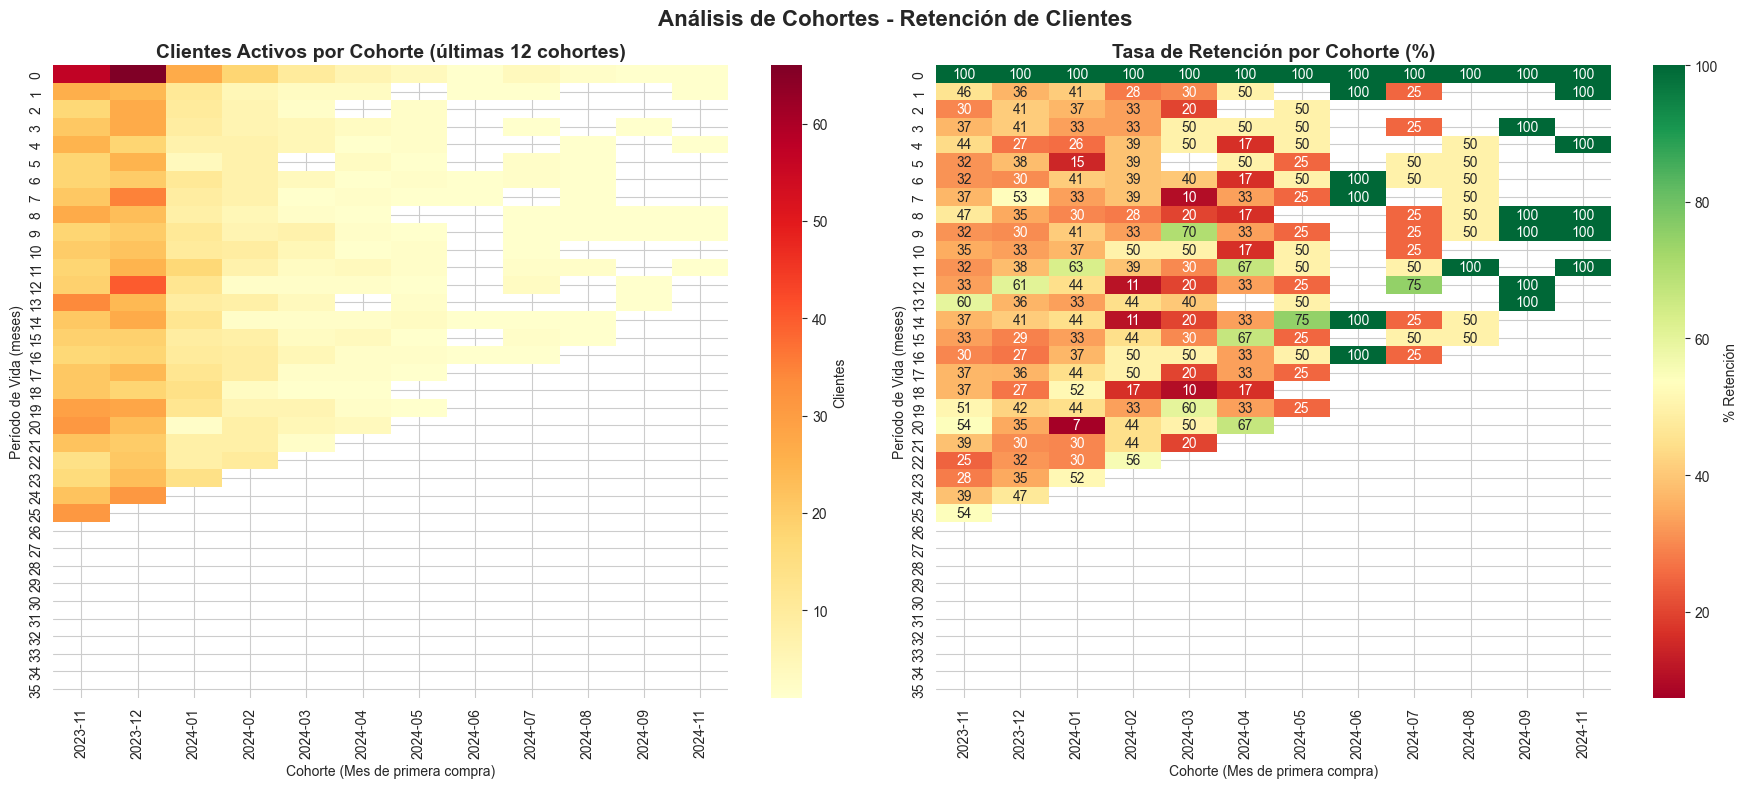


📊 Retención Promedio por Período de Vida:
   Mes  0: 100.0%
   Mes  1:  42.8%
   Mes  2:  36.4%
   Mes  3:  40.6%
   Mes  4:  40.6%
   Mes  5:  36.8%
   Mes  6:  40.5%
   Mes  7:  39.4%
   Mes  8:  40.7%
   Mes  9:  42.8%
   Mes 10:  37.7%
   Mes 11:  47.0%
   Mes 12:  39.7%


In [30]:
# ============================================================
# 10. ANÁLISIS DE COHORTES
# ============================================================

print("=" * 70)
print("📊 ANÁLISIS DE COHORTES")
print("=" * 70)

# === Crear cohortes por mes de primera compra ===
# Identificar primera compra de cada cliente
primera_compra = df.groupby('id_cliente')['fecha'].min().reset_index()
primera_compra.columns = ['id_cliente', 'primera_compra']
primera_compra['cohorte'] = primera_compra['primera_compra'].dt.to_period('M')

# Unir al dataset
df_cohortes = df.merge(primera_compra[['id_cliente', 'cohorte', 'primera_compra']], on='id_cliente')

# Calcular período de vida (meses desde primera compra)
df_cohortes['periodo_vida'] = (
    (df_cohortes['fecha'].dt.year - df_cohortes['primera_compra'].dt.year) * 12 +
    (df_cohortes['fecha'].dt.month - df_cohortes['primera_compra'].dt.month)
)

# === Matriz de retención ===
cohorte_retencion = df_cohortes.groupby(['cohorte', 'periodo_vida'])['id_cliente'].nunique().unstack()

# Calcular % de retención respecto al tamaño de la cohorte
cohorte_size = cohorte_retencion.iloc[:, 0]
cohorte_retencion_pct = cohorte_retencion.divide(cohorte_size, axis=0) * 100

print(f"✅ Cohortes calculadas: {len(cohorte_retencion)} cohortes mensuales")
print(f"   Períodos de vida: 0 a {cohorte_retencion.shape[1]-1} meses")

# === Heatmap de retención ===
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Retención absoluta
sns.heatmap(cohorte_retencion.iloc[-12:].T, annot=False, fmt='.0f', cmap='YlOrRd', 
            ax=axes[0], cbar_kws={'label': 'Clientes'})
axes[0].set_title('Clientes Activos por Cohorte (últimas 12 cohortes)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cohorte (Mes de primera compra)')
axes[0].set_ylabel('Período de Vida (meses)')

# Retención porcentual
sns.heatmap(cohorte_retencion_pct.iloc[-12:].T, annot=True, fmt='.0f', cmap='RdYlGn', 
            ax=axes[1], vmax=100, cbar_kws={'label': '% Retención'})
axes[1].set_title('Tasa de Retención por Cohorte (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cohorte (Mes de primera compra)')
axes[1].set_ylabel('Período de Vida (meses)')

plt.suptitle('Análisis de Cohortes - Retención de Clientes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# === Tasa de retención promedio por período de vida ===
retencion_promedio = cohorte_retencion_pct.mean(axis=0)
print("\n📊 Retención Promedio por Período de Vida:")
for periodo, ret in retencion_promedio.items():
    if periodo <= 12:
        print(f"   Mes {periodo:2d}: {ret:5.1f}%")

# KPIs Estratégicos

In [31]:
# ============================================================
# 11. KPIs ESTRATÉGICOS
# ============================================================

print("=" * 70)
print("📊 KPIs ESTRATÉGICOS - ANDINARETAIL S.A.C.")
print("=" * 70)

# === Calcular KPIs ===
fecha_max = df['fecha'].max()
fecha_min = df['fecha'].min()
meses_total = round((fecha_max - fecha_min).days / 30.44, 1)

# Clientes activos (compraron en últimos 3 meses)
corte_activo = fecha_max - timedelta(days=90)
clientes_activos = df[df['fecha'] >= corte_activo]['id_cliente'].nunique()
clientes_inactivos = rfm[rfm['recency'] > 90]['id_cliente'].nunique()
clientes_totales = rfm['id_cliente'].nunique()

kpis = {
    '📈 Ventas Totales': f"S/.{df['monto_total'].sum():,.0f}",
    '📈 Ventas Mensuales Promedio': f"S/.{df_mensual['ventas_totales'].mean():,.0f}" if 'df_mensual' in locals() else "N/A",
    '💰 Margen Total': f"S/.{df['margen'].sum():,.0f}",
    '💰 Margen Promedio (%)': f"{df['margen_pct'].mean():.1f}%",
    '🛒 Ticket Promedio': f"S/.{df['monto_total'].mean():,.2f}",
    '👤 Ingreso Promedio por Cliente': f"S/.{rfm['monetary'].mean():,.2f}",
    '👥 Clientes Totales': f"{clientes_totales:,}",
    '🟢 Clientes Activos (últ. 90 días)': f"{clientes_activos:,} ({clientes_activos/clientes_totales*100:.1f}%)",
    '🔴 Clientes Inactivos (>90 días)': f"{clientes_inactivos:,} ({clientes_inactivos/clientes_totales*100:.1f}%)",
    '🔄 Frecuencia Promedio (compras/cliente)': f"{rfm['frequency'].mean():.1f}",
    '📦 Transacciones Totales': f"{len(df):,}",
    '📅 Período Analizado': f"{fecha_min.date()} a {fecha_max.date()} ({meses_total} meses)",
    '🏬 Tiendas': f"{df['id_tienda'].nunique():,}",
    '🛍️ Productos Únicos': f"{df['id_producto'].nunique():,}",
}

for kpi, valor in kpis.items():
    print(f"   {kpi}: {valor}")

# === KPIs adicionales de salud del negocio ===
print(f"\n📊 INDICADORES DE SALUD DEL NEGOCIO:")
tasa_inactividad = clientes_inactivos / clientes_totales * 100
print(f"   Tasa de Inactividad: {tasa_inactividad:.1f}% {'🔴 ALTA' if tasa_inactividad > 40 else '🟢 SALUDABLE'}")
if 'df_mensual' in locals():
    crecimiento = ((df_mensual['ventas_totales'].iloc[-1] / df_mensual['ventas_totales'].iloc[0]) - 1) * 100
    print(f"   Crecimiento en el período: {crecimiento:+.1f}%")

📊 KPIs ESTRATÉGICOS - ANDINARETAIL S.A.C.
   📈 Ventas Totales: S/.80,369,023
   📈 Ventas Mensuales Promedio: S/.2,232,473
   💰 Margen Total: S/.32,147,609
   💰 Margen Promedio (%): 40.0%
   🛒 Ticket Promedio: S/.322.17
   👤 Ingreso Promedio por Cliente: S/.5,357.93
   👥 Clientes Totales: 15,000
   🟢 Clientes Activos (últ. 90 días): 11,985 (79.9%)
   🔴 Clientes Inactivos (>90 días): 3,015 (20.1%)
   🔄 Frecuencia Promedio (compras/cliente): 16.7
   📦 Transacciones Totales: 250,137
   📅 Período Analizado: 2023-01-01 a 2025-12-31 (36.0 meses)
   🏬 Tiendas: 12
   🛍️ Productos Únicos: 800

📊 INDICADORES DE SALUD DEL NEGOCIO:
   Tasa de Inactividad: 20.1% 🟢 SALUDABLE
   Crecimiento en el período: +81.2%


## 📊 Análisis de Cohortes - Insights y Recomendaciones

### 📌 Principales Hallazgos

#### 🔴 Críticos (Acción Inmediata)

1. **Caída abrupta en retención temprana (Mes 1):**
   - **Dato:** La retención pasa de **100% (Mes 0) a 42.8% (Mes 1)**. El mayor abandono ocurre después de la primera compra.
   - **Impacto:** Se pierde más de la mitad de los clientes nuevos en el primer mes.
   - **Acción:** Implementar **Onboarding** inmediato (correo de bienvenida + descuento exclusivo para segunda compra) para asegurar la retención temprana.

2. **Tasa de inactividad vs Tasa de crecimiento:**
   - **Dato:** 20.1% de inactivos (>90 días) vs +81.2% de crecimiento en el período.
   - **Diagnóstico:** El negocio crece rápidamente en captación de nuevos clientes, pero tiene una **fuga constante**. El 20.1% representa **3,015 clientes** que generaban ingresos recurrentes.
   - **Acción:** Lanzar campaña de reactivación masiva para el segmento **RFM: "En Riesgo" y "Perdidos"** antes de que sean irrecuperables.

---

#### 🟡 Importantes (Plan a 30 días)

3. **Mes 11 es el pico de retención (47.0%):**
   - **Dato:** La retención sube en el mes 11 (coincidiendo con el inicio de la temporada navideña).
   - **Acción:** Planificar campañas de fidelización y recordatorios preventivos en el mes 10 para capitalizar este rebote estacional.

4. **Ingreso por cliente vs Frecuencia:**
   - **Dato:** Ingreso promedio por cliente de **S/5,357** con una frecuencia promedio de **16.7 compras**.
   - **Acción:** Los clientes compran seguido, pero el ticket es bajo. Implementar estrategias de **up-selling y cross-selling** para aumentar el ticket promedio (actualmente S/322.17).

---

#### 🟢 Estratégicos (Plan a 90 días)

5. **Cohortes recientes vs antiguas:**
   - **Dato:** La retención se mantiene relativamente estable entre el 36% y 42% en los meses posteriores, sin una tendencia clara de mejora.
   - **Acción:** Realizar un análisis de NPS o encuestas de satisfacción enfocadas en las cohortes más recientes para detectar si la experiencia del cliente (CX) ha empeorado en el último año.

---

### 🚀 Plan de Acción Resumido

| Prioridad | Acción | KPI a monitorear |
| :--- | :--- | :--- |
| 🔴 **Urgente** | Automatizar email de bienvenida + descuento para 2da compra (Onboarding). | Retención Mes 1 (actual 42.8%). |
| 🔴 **Urgente** | Reactivar a los 3,015 clientes inactivos (>90 días). | Reducir tasa de inactividad. |
| 🟡 **30 días** | Campaña preventiva en Mes 10 para aprovechar el pico del Mes 11. | Retención Mes 11. |
| 🟢 **90 días** | Encuesta de satisfacción a cohortes recientes. | Tasa de retención de nuevas cohortes. |

---

### 📊 Resumen Ejecutivo de Salud del Negocio

El negocio muestra un **crecimiento sólido (+81.2%)**, pero enfrenta un **desafío crítico de retención temprana**. El 57.2% de los nuevos clientes no vuelve a comprar después del primer mes. Si se logra mejorar esa retención temprana (de 42.8% a 60%), el valor de vida del cliente (LTV) y los ingresos totales aumentarían drásticamente sin necesidad de invertir más en adquisición.

# 📊 Conclusiones y Plan de Acción: Análisis Descriptivo y Diagnóstico de Negocio

---

## 📈 ¿Qué ocurrió?

1. **Tendencia a la baja:** Crecimiento estable hasta mediados de 2024, seguido de una **caída sostenida**. Problema estructural que requiere acción urgente.

2. **Estacionalidad dominante:** Picos de ventas muy marcados en **Julio y Diciembre**. No existe efecto de arrastre entre meses consecutivos.

3. **Dependencia extrema (Pareto):**
   - **146 productos (18.2%)** generan el 80% de las ventas.
   - **2 categorías ("Electrohogar" y "Hogar")** concentran el 80% de la facturación.
   - **8,584 clientes (57.2%)** generan el 80% de los ingresos.

4. **Crisis de retención (RFM):**
   - **Clientes "En Riesgo" (21.9%)** y **"Perdidos" (10.9%)** = 32.8% de la base, generan el **26.4% de los ingresos**.
   - **"Champions" (12.7%)** y **"Leales" (20.2%)** aportan el 45.7% de ingresos (por debajo del 60-70% esperado).

5. **Clustering:** 3 clusters de clientes identificados, confirmando comportamientos diferenciados.

---

## 🤔 ¿Por qué ocurrió?

| Problema | Causa Raíz |
|----------|------------|
| Caída de tendencia | Competencia, estancamiento de mix de productos, pérdida de atractivo para clientes de alto valor |
| Dependencia de 2 categorías | Falta de desarrollo de otras categorías; riesgo crítico ante cualquier afectación en Electrohogar/Hogar |
| Alta tasa de "En Riesgo" y "Perdidos" | Campañas de retención insuficientes o inexistentes |
| Bajo rendimiento de "Champions" y "Leales" | Oferta de venta cruzada y *up-selling* ineficaz |
| Estacionalidad sin efecto de arrastre | Campañas aisladas que no generan lealtad recurrente |

---

## 🛒 ¿Qué productos y categorías potenciar?

| Categoría | Acción | Estrategia |
|-----------|--------|------------|
| **Electrohogar y Hogar** | Apalancar categorías dominantes | Negociar con proveedores, asegurar stock, identificar productos estrella |
| **Abarrotes, Bebidas, etc.** | Dinamizar categorías de bajo peso | Promociones de venta cruzada: "Descuento en Abarrotes al comprar un electrodoméstico" |
| **Cola larga de productos** | Desarrollar estrategia selectiva | Analizar rentabilidad, reposicionar productos de entrada, descontinuar no rentables |

---

## 📍 ¿Qué ciudades requieren intervención?

*El análisis actual no incluye desagregación por ciudad. Se recomienda:*

| Foco | Acción |
|------|--------|
| Ciudades con mayor caída de tendencia | Analizar si el declive es generalizado o localizado |
| Ciudades con alta concentración de clientes "En Riesgo" | Campañas de reactivación localizadas |
| Ciudades con ticket promedio bajo | Evaluar estrategia comercial y de precios |
| Ciudades con alta dependencia de Electrohogar/Hogar | Priorizar diversificación de oferta |

---

## 🚀 Plan de Acción Recomendado

| Prioridad | Acción | Área Responsable | Plazo |
|-----------|--------|------------------|-------|
| 🔴 **Crítica** | **Campaña de Reactivación Masiva:** Dirigida a segmentos **"En Riesgo"** y **"Perdidos"**. | Marketing | **Inmediato (1-2 meses)** |
| 🔴 **Crítica** | **Investigación de Caída de Tendencia:** Estudio de mercado para identificar causas del declive desde mediados de 2024. | Estrategia / Marketing | **Inmediato (1-3 meses)** |
| 🟠 **Alta** | **Programa de Fidelización VIP:** Para segmentos **"Champions"** y **"Leales"**. | Marketing / Producto | **Corto Plazo (3-6 meses)** |
| 🟠 **Alta** | **Análisis de Mix de Producto:** Revisar categorías **"Electrohogar"** y **"Hogar"**, negociar con proveedores, analizar rentabilidad de cola larga. | Producto / Compras | **Corto Plazo (3-6 meses)** |
| 🟡 **Media** | **Estrategia de Ventas Cruzadas:** Vincular **"Electrohogar"** y **"Hogar"** con el resto del portafolio. | Marketing / Producto | **Mediano Plazo (6-12 meses)** |
| 🟡 **Media** | **Planificación Estacional:** Calendario anual basado en picos de **Julio** y **Diciembre**. Usar valles para campañas de *clearance*. | Marketing / Compras | **Continuo** |
| 🟢 **Baja** | **Análisis de Rentabilidad por Ciudad:** Focalizar acciones de marketing y detectar áreas de riesgo. | BI / Marketing | **Mediano Plazo (6-12 meses)** |

---

## 📊 Resumen Ejecutivo

| Indicador | Situación Actual | Riesgo |
|-----------|------------------|--------|
| Tendencia | Caída desde mediados de 2024 | 🔴 Alto |
| Estacionalidad | Picos en Julio y Diciembre | 🟡 Medio |
| Concentración | 2 categorías = 80% de ingresos | 🔴 Alto |
| Clientes "En Riesgo" | 21.9% de la base | 🔴 Alto |
| Clientes "Perdidos" | 10.9% de la base | 🔴 Alto |
| Clientes "Champions" | 12.7% de la base | 🟢 Bajo |

### ⚠️ Alertas Críticas
1. **Fuga de Clientes:** 32.8% de la base está en riesgo de pérdida.
2. **Dependencia Extrema:** El negocio depende de 2 categorías para su supervivencia.
3. **Pérdida de Impulso:** La tendencia a la baja requiere intervención estratégica inmediata.

### 🎯 Próximos Pasos Inmediatos
1. **Semana 1:** Diseñar campaña de reactivación para "En Riesgo".
2. **Mes 1:** Iniciar estudio de mercado para identificar causas de caída de tendencia.
3. **Mes 2:** Negociar con proveedores de "Electrohogar" y "Hogar".
4. **Trimestre:** Implementar programa piloto de fidelización para "Champions".

# 📊 Patrones Históricos, Estacionalidad y Segmentos de Clientes

---

## 📅 ¿Qué patrones históricos y estacionales explican el desempeño?

### 1. Estacionalidad Dominante (Anual)

| Hallazgo | Dato | Implicancia |
|----------|------|-------------|
| **Picos principales** | Julio y Diciembre | Campañas de Fiestas Patrias y Navidad/Fin de Año |
| **Correlación Lag 12** | 0.7 (fuerte) | Ciclo anual muy marcado |
| **Sin efecto de arrastre** | Lag 1: bajo | Campañas no generan momentum al mes siguiente |

**Conclusión:** El negocio es altamente estacional (ciclo anual). La estrategia comercial debe ser anual, no mensual.

---

### 2. Tendencia (Largo Plazo)

| Período | Comportamiento |
|---------|----------------|
| 2023 - mediados 2024 | Crecimiento estable |
| Mediados 2024 - 2025 | **Caída sostenida** (señal de alerta estructural) |

**Conclusión:** La caída no es estacional (se compara con el mismo período del año anterior). Indica problemas estructurales: competencia, saturación o pérdida de clientes de alto valor.

---

### 3. Residuo (Irregularidades)

| Hallazgo | Implicancia |
|----------|-------------|
| Mayor volatilidad en 2024-2025 | El negocio se está volviendo más impredecible |

---

## 👥 ¿Qué segmentos de clientes existen?

### Segmentación RFM: 8 Segmentos

| Segmento | % Clientes | % Ingresos | Perfil |
|----------|------------|------------|--------|
| 💎 **Leales** | 20.2% | 23.8% | Mayor frecuencia (20.5 compras) |
| ⚠️ **En Riesgo** | 21.9% | 22.0% | 110 días de inactividad |
| 🏆 **Champions** | 12.7% | 21.9% | Alto gasto (S/.9,263) y frecuencia |
| 🌟 **Potenciales** | 9.5% | 14.2% | Ticket más alto (S/.552) |
| 📦 **Otros** | 10.6% | 6.6% | Compra esporádica |
| 🌱 **Prometedores** | 10.3% | 5.4% | Recientes (9.2 días) |
| ❌ **Perdidos** | 10.9% | 4.4% | >126 días sin comprar |
| 💤 **Dormidos** | 3.9% | 1.6% | Bajo gasto y frecuencia |

### Clustering (K-Means): 3 Clusters

| Cluster | % Clientes | % Ingresos | Perfil |
|---------|------------|------------|--------|
| **Cluster 1** | 34.2% | 53.6% | Alto valor (Champions + Leales) |
| **Cluster 2** | 15.0% | 12.1% | En riesgo/Perdidos (173 días de inactividad) |
| **Cluster 0** | 50.8% | 34.2% | Base masiva de volumen |

---

## 📉 ¿Por qué cae el margen en ciertas plazas?

⚠️ **El análisis actual NO incluye desagregación por ciudad/plaza.**

### Causas Probables (Inferidas de hallazgos generales)

| Causa | Explicación |
|-------|-------------|
| **1. Concentración de categorías de bajo margen** | Plazas con mayor peso de "Electrohogar" podrían tener márgenes más bajos |
| **2. Canales de venta de menor margen** | Plazas con mayor proporción de Tienda Física vs. Online |
| **3. Descuentos agresivos** | Plazas competitivas usando descuentos para mantener volumen |
| **4. Mezcla de productos** | Plazas que venden más productos de "cola larga" con menor rotación |
| **5. Costos operativos** | Plazas con mayor costo de operación (alquiler, personal, logística) |

---

## 🎯 Resumen de Insights Clave

| Dimensión | Insight Clave |
|-----------|---------------|
| **Estacionalidad** | Ciclo anual dominante; picos en Julio y Diciembre |
| **Tendencia** | Caída desde mediados 2024 → señal de alerta estructural |
| **Segmentos críticos** | 32.8% de clientes en riesgo (En Riesgo + Perdidos) |
| **Dependencia** | 2 categorías = 80% de ingresos |
| **Margen por plaza** | No analizado → requiere estudio específico |

---

## ⚠️ Alertas Críticas

1. **Fuga de Clientes:** 32.8% de la base está en riesgo de pérdida.
2. **Dependencia Extrema:** 2 categorías concentran el 80% de la facturación.
3. **Pérdida de Impulso:** Tendencia a la baja desde mediados de 2024.
4. **Sin análisis por plaza:** No se puede determinar caída de margen por ciudad.

---

## 🎯 Próximos Pasos Inmediatos

| Prioridad | Acción | Plazo |
|-----------|--------|-------|
| 🔴 **Crítica** | Campaña de reactivación para "En Riesgo" y "Perdidos" | 1-2 meses |
| 🔴 **Crítica** | Investigar causas de caída de tendencia | 1-3 meses |
| 🟠 **Alta** | Programa de fidelización para "Champions" y "Leales" | 3-6 meses |
| 🟠 **Alta** | Analizar rentabilidad por categoría y canal | 3-6 meses |
| 🟡 **Media** | Solicitar análisis de rentabilidad por plaza/ciudad | 6-12 meses |